# AgriTech Capstone Project

Data analysis and machine learning study of crop productivity, seasonal performance, irrigation infrastructure, rainfall/precipitation patterns, and fertilizer usage.


> **Reproducibility note:** The notebook expects the project datasets under `data/`. The original machine-specific Windows paths have been replaced with repository-relative paths. If the source datasets cannot be redistributed, keep them out of Git and follow the instructions in `data/README.md`.


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load datasets
from pathlib import Path

# Keep all project datasets in the repository's data/ directory.
# Change this path only if your data is stored elsewhere.
DATA_DIR = Path("data")

crop_df = pd.read_csv(DATA_DIR / "crop_production.csv")
rainfall_df = pd.read_csv(DATA_DIR / "rainfall.csv")
precipitation_df = pd.read_csv(DATA_DIR / "precipitation.csv")
fertilizer_df = pd.read_csv(DATA_DIR / "fertilizer.csv")
irrigation_df = pd.read_csv(DATA_DIR / "irrigation.csv")
faostat_df = pd.read_excel(DATA_DIR / "faostat.xlsx")


In [ ]:
datasets = {

    "Crop_Production": crop_df,

    "Rainfall": rainfall_df,

    "Precipitation": precipitation_df,

    "Fertilizer": fertilizer_df,

    "Irrigation": irrigation_df,

    "FAOSTAT": faostat_df

}

for name, df in datasets.items():

    print(name)


    print(df.shape)

    

Crop_Production
(104, 17)
Rainfall
(63, 15)
Precipitation
(85, 4)
Fertilizer
(62, 15)
Irrigation
(17, 13)
FAOSTAT
(5659, 15)


In [ ]:
for name, df in datasets.items():
    print(f"--- {name} ---")
    print(df.head())   
    print("\n")

--- Crop_Production ---
    Crop  Season  Area-2020-21  Area-2021-22  Area-2022-23  Area-2023-24  \
0   Rice  Kharif        403.58        410.38        404.03        407.34   
1   Rice    Rabi         54.11         52.40         43.28         40.76   
2   Rice  Summer           NaN           NaN         31.01         30.18   
3   Rice   Total        457.69        462.79        478.32        478.28   
4  Wheat    Rabi        311.25        304.59        314.01        318.33   

   Area-2024-25  Production-2020-21  Production-2021-22  Production-2022-23  \
0        434.13             1052.08             1110.01             1105.12   
1         44.74              191.60              184.71              150.04   
2         35.36                 NaN                 NaN              102.40   
3        514.23             1243.68             1294.71             1357.55   
4        327.61             1095.86             1077.42             1105.54   

   Production-2023-24  Production-2024-25  Y

In [ ]:
yield_cols = [col for col in crop_df.columns if "Yield" in col]

crop_df[yield_cols] = crop_df[yield_cols] / 1000

print("Yield converted from kg/ha to tonnes/ha")

Yield converted from kg/ha to tonnes/ha


In [ ]:
# Check Columns
for name, df in datasets.items():

    print(name)

    print(df.columns.tolist())

Crop_Production
['Crop', 'Season', 'Area-2020-21', 'Area-2021-22', 'Area-2022-23', 'Area-2023-24', 'Area-2024-25', 'Production-2020-21', 'Production-2021-22', 'Production-2022-23', 'Production-2023-24', 'Production-2024-25', 'Yield-2020-21', 'Yield-2021-22', 'Yield-2022-23', 'Yield-2023-24', 'Yield-2024-25']
Rainfall
['country', 'Code', 'year', 'Wheat | 00000015 || Yield | 005412 || tonnes per hectare', 'Rice | 00000027 || Yield | 005412 || tonnes per hectare', 'Bananas | 00000486 || Yield | 005412 || tonnes per hectare', 'Maize | 00000056 || Yield | 005412 || tonnes per hectare', 'Soybeans | 00000236 || Yield | 005412 || tonnes per hectare', 'Potatoes | 00000116 || Yield | 005412 || tonnes per hectare', 'Beans, dry | 00000176 || Yield | 005412 || tonnes per hectare', 'Peas, dry | 00000187 || Yield | 005412 || tonnes per hectare', 'Cassava | 00000125 || Yield | 005412 || tonnes per hectare', 'Cocoa beans | 00000661 || Yield | 005412 || tonnes per hectare', 'Barley | 00000044 || Yield |

In [ ]:
#Check Data types
for name, df in datasets.items():

    print(name)

    print(df.dtypes)

Crop_Production
Crop                      str
Season                    str
Area-2020-21          float64
Area-2021-22          float64
Area-2022-23          float64
Area-2023-24          float64
Area-2024-25          float64
Production-2020-21    float64
Production-2021-22    float64
Production-2022-23    float64
Production-2023-24    float64
Production-2024-25    float64
Yield-2020-21         float64
Yield-2021-22         float64
Yield-2022-23         float64
Yield-2023-24         float64
Yield-2024-25         float64
dtype: object
Rainfall
country                                                               str
Code                                                                  str
year                                                                int64
Wheat | 00000015 || Yield | 005412 || tonnes per hectare          float64
Rice | 00000027 || Yield | 005412 || tonnes per hectare           float64
Bananas | 00000486 || Yield | 005412 || tonnes per hectare        float64
Maize |

In [ ]:
# Missing Values
for name, df in datasets.items():

    print(name)

    print(df.isnull().sum())

Crop_Production
Crop                   0
Season                 0
Area-2020-21          22
Area-2021-22          16
Area-2022-23           0
Area-2023-24           0
Area-2024-25           6
Production-2020-21    22
Production-2021-22    16
Production-2022-23     0
Production-2023-24     0
Production-2024-25     6
Yield-2020-21         22
Yield-2021-22         16
Yield-2022-23          0
Yield-2023-24          0
Yield-2024-25          6
dtype: int64
Rainfall
country                                                            0
Code                                                               0
year                                                               0
Wheat | 00000015 || Yield | 005412 || tonnes per hectare           0
Rice | 00000027 || Yield | 005412 || tonnes per hectare            0
Bananas | 00000486 || Yield | 005412 || tonnes per hectare         0
Maize | 00000056 || Yield | 005412 || tonnes per hectare           0
Soybeans | 00000236 || Yield | 005412 || tonnes per he

In [ ]:
## Null  Value

for name, df in datasets.items():
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
# Missing Values 
for name, df in datasets.items():

    print(name)

    print(df.isnull().sum())

Crop_Production
Crop                  0
Season                0
Area-2020-21          0
Area-2021-22          0
Area-2022-23          0
Area-2023-24          0
Area-2024-25          0
Production-2020-21    0
Production-2021-22    0
Production-2022-23    0
Production-2023-24    0
Production-2024-25    0
Yield-2020-21         0
Yield-2021-22         0
Yield-2022-23         0
Yield-2023-24         0
Yield-2024-25         0
dtype: int64
Rainfall
country                                                           0
Code                                                              0
year                                                              0
Wheat | 00000015 || Yield | 005412 || tonnes per hectare          0
Rice | 00000027 || Yield | 005412 || tonnes per hectare           0
Bananas | 00000486 || Yield | 005412 || tonnes per hectare        0
Maize | 00000056 || Yield | 005412 || tonnes per hectare          0
Soybeans | 00000236 || Yield | 005412 || tonnes per hectare       0
Potatoes |

In [ ]:
df["Year"] = df["Year"].astype(int)

In [ ]:
for df in [rainfall_df, fertilizer_df, precipitation_df]:
    df["country"] = df["country"].astype(str)
    df["Code"] = df["Code"].astype(str)

In [ ]:
faostat_df["Year"] = faostat_df["Year"].astype(int)
faostat_df["Area"] = faostat_df["Area"].astype(str)
faostat_df["Item"] = faostat_df["Item"].astype(str)
faostat_df["Element"] = faostat_df["Element"].astype(str)

In [ ]:
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.select_dtypes(include=['string','object','category']).isnull().sum())


Crop_Production
Crop      0
Season    0
dtype: int64

Rainfall
country    0
Code       0
dtype: int64

Precipitation
country    0
Code       0
dtype: int64

Fertilizer
country    0
Code       0
dtype: int64

Irrigation
Sl. No.     0
State/UT    0
dtype: int64

FAOSTAT
Domain Code            0
Domain                 0
Area                   0
Element                0
Item Code (CPC)        0
Item                   0
Unit                   0
Flag                   0
Flag Description       0
Note                5386
dtype: int64


In [ ]:
# Duplicate Analysis
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.duplicated().sum())
    print('No Duplicates are present')


Crop_Production
0
No Duplicates are present

Rainfall
0
No Duplicates are present

Precipitation
0
No Duplicates are present

Fertilizer
0
No Duplicates are present

Irrigation
0
No Duplicates are present

FAOSTAT
0
No Duplicates are present


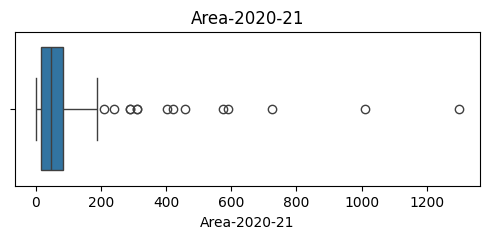

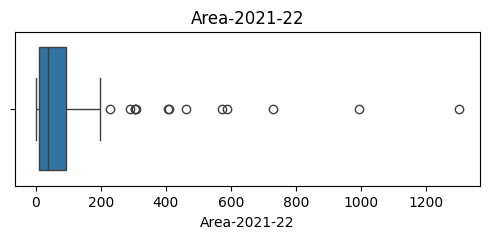

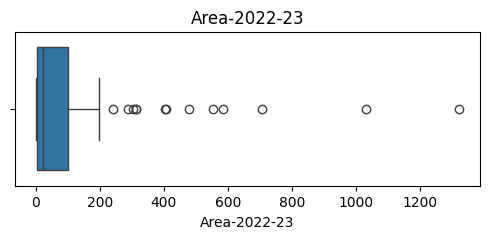

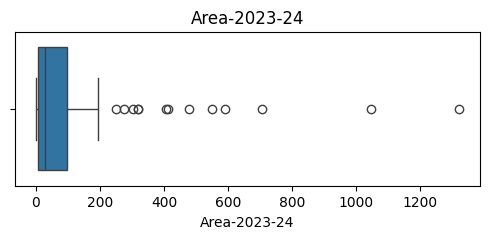

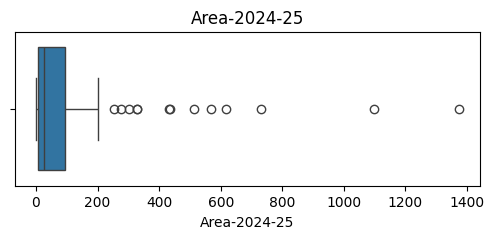

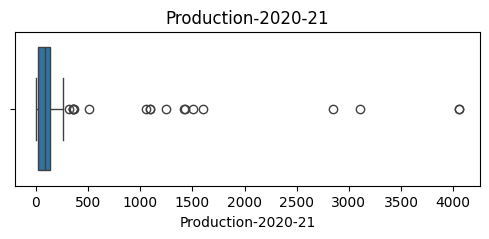

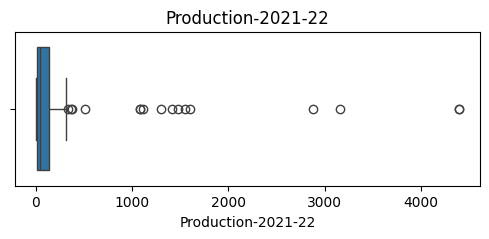

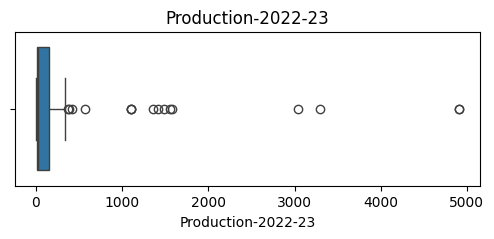

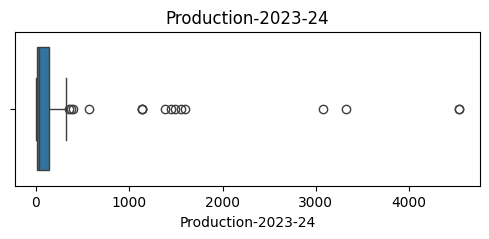

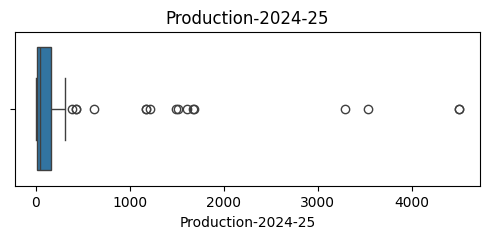

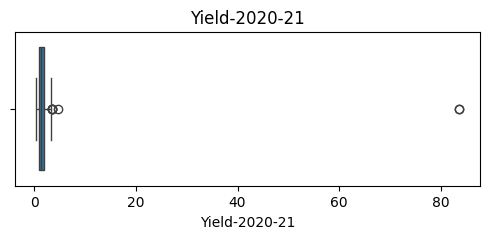

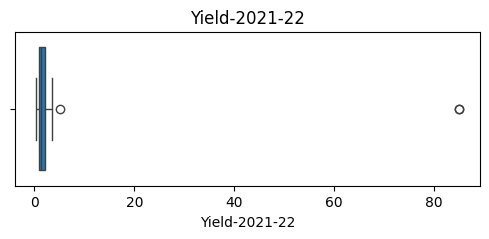

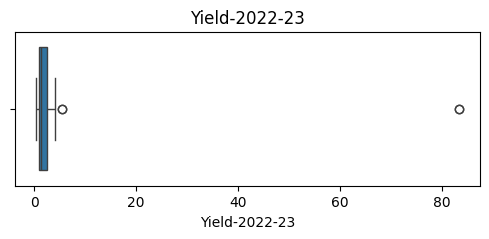

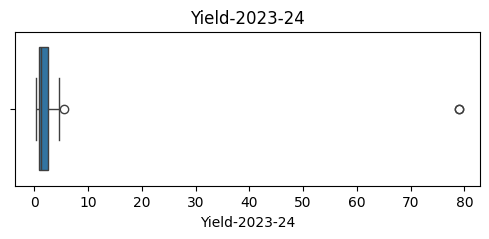

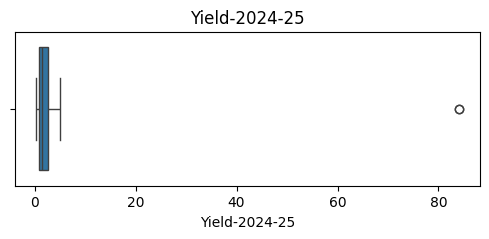

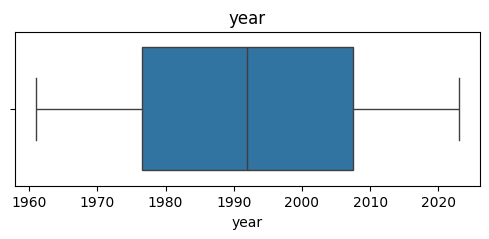

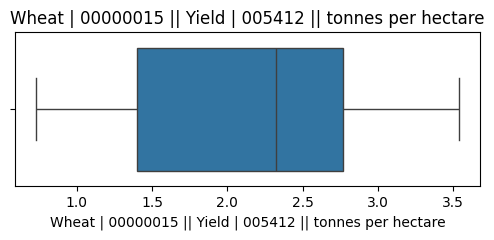

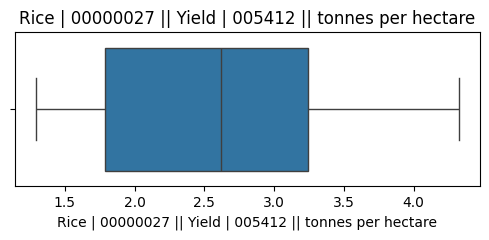

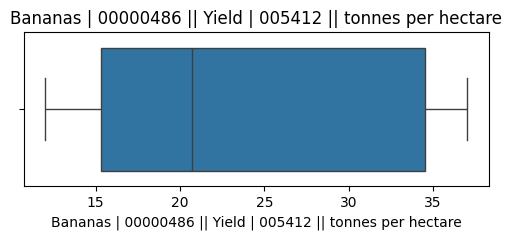

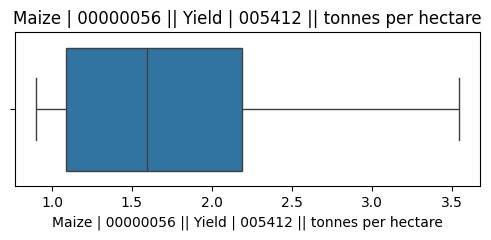

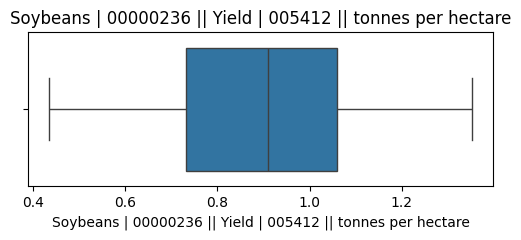

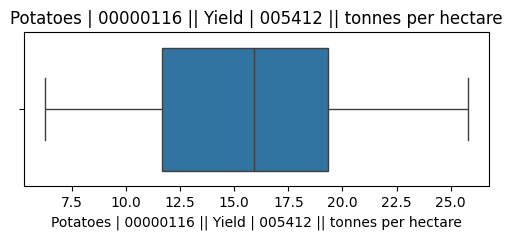

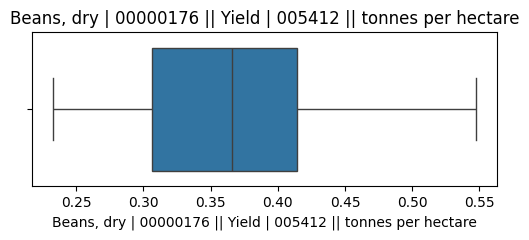

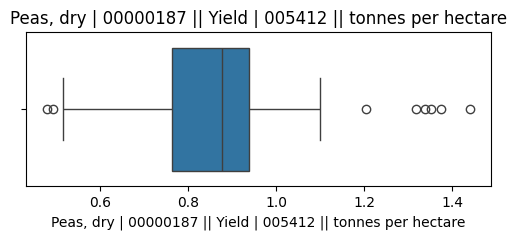

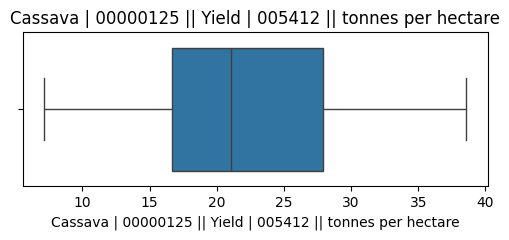

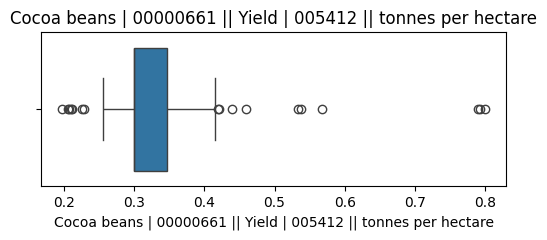

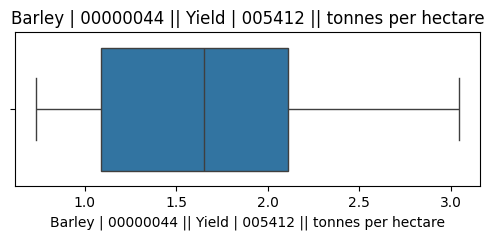

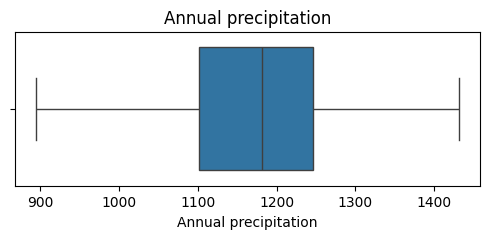

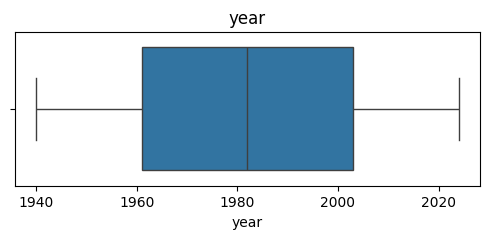

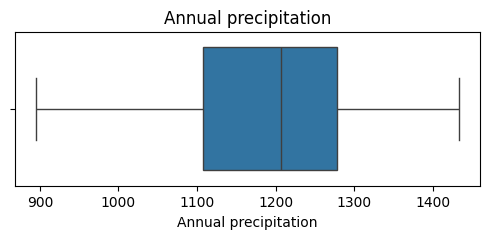

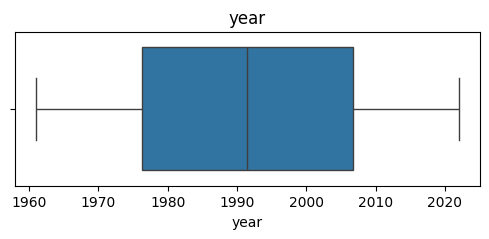

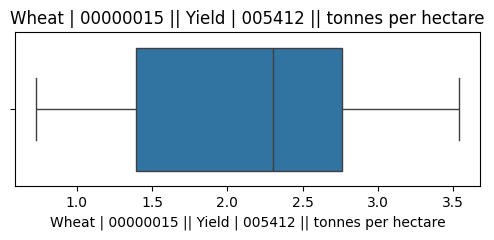

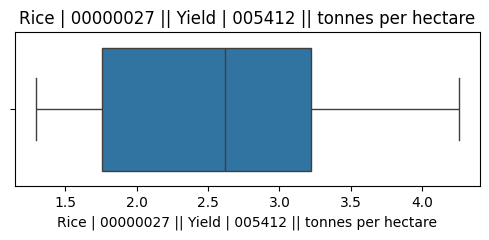

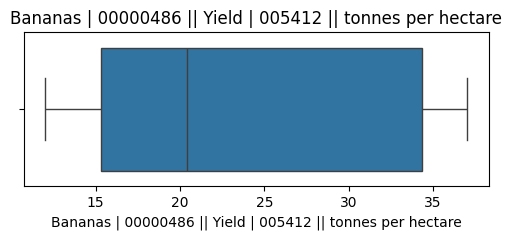

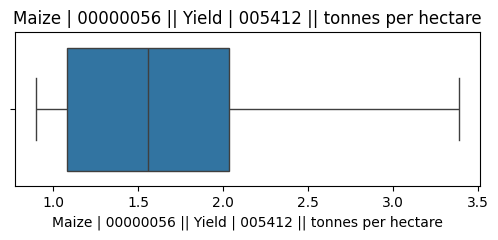

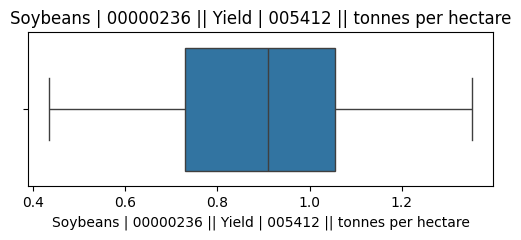

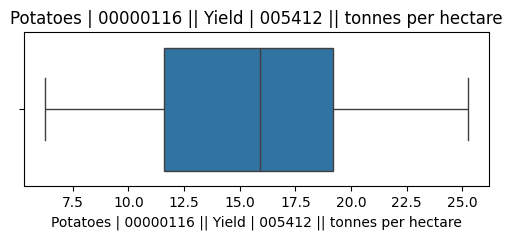

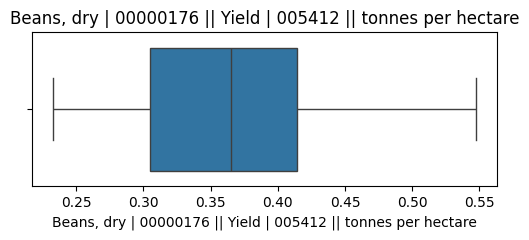

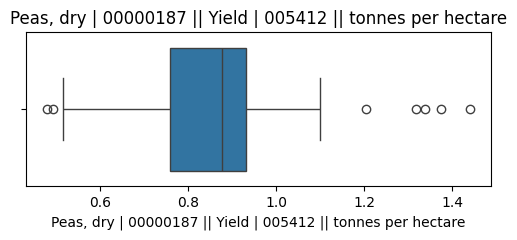

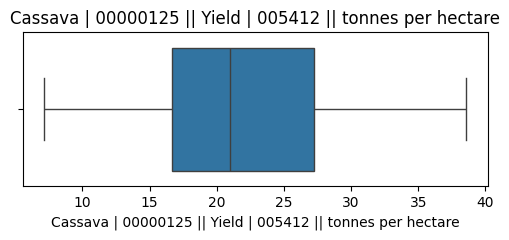

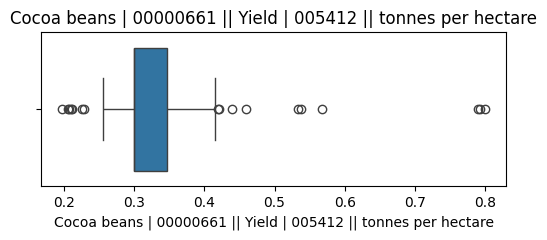

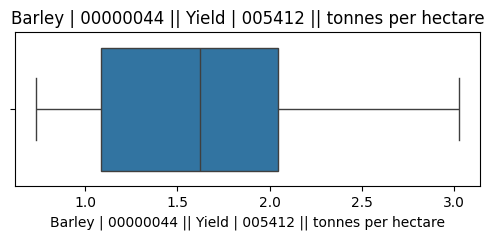

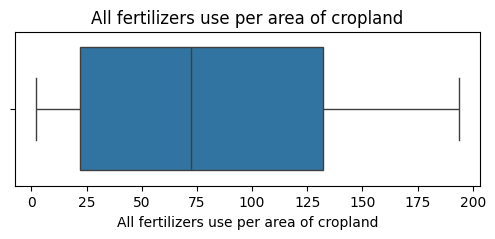

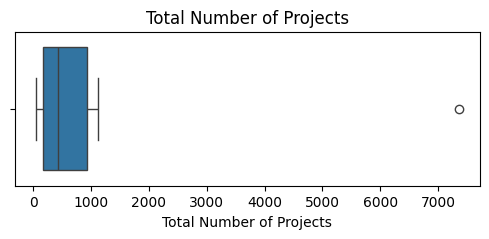

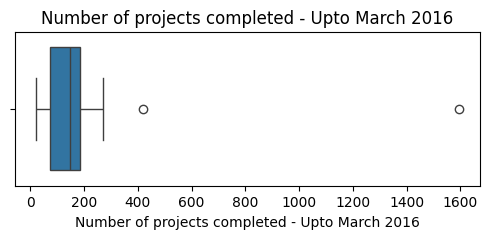

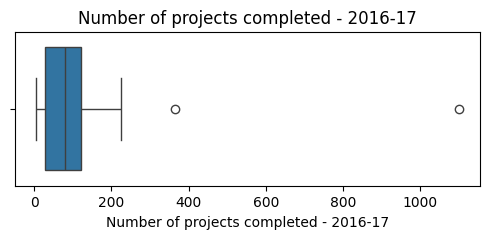

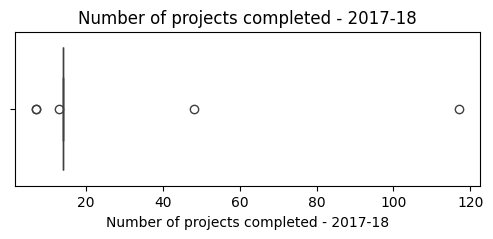

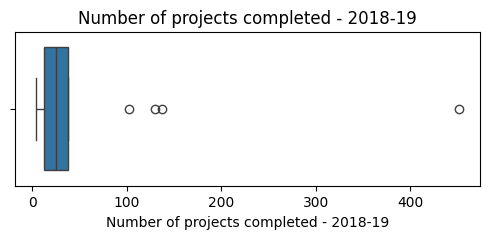

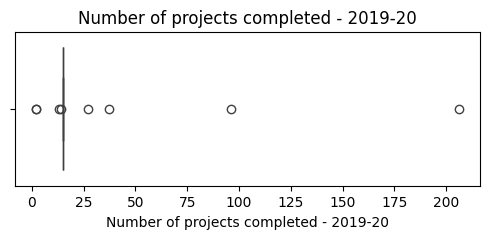

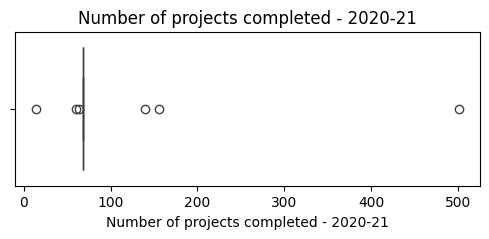

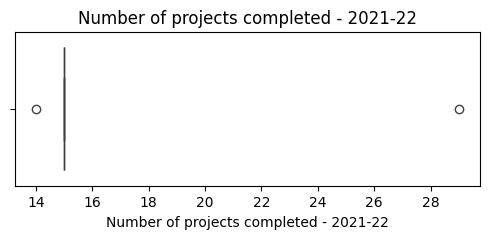

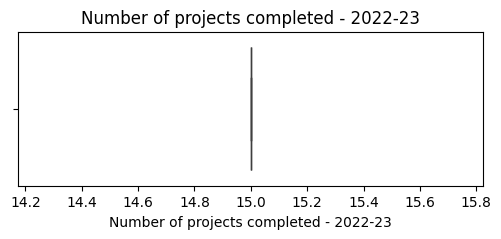

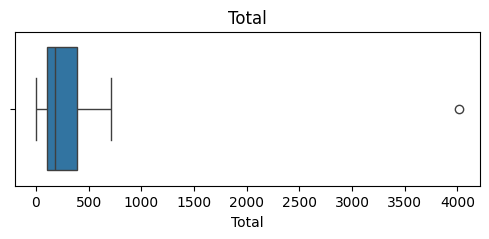

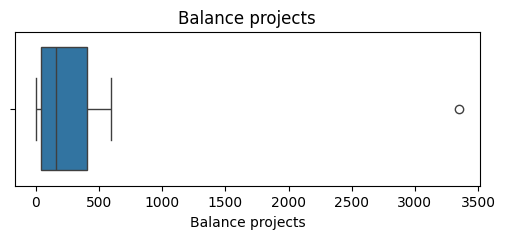

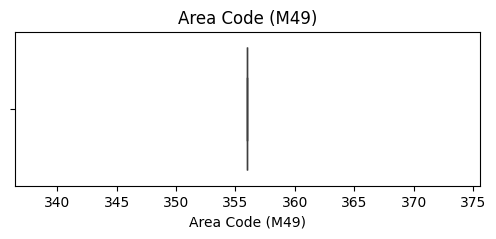

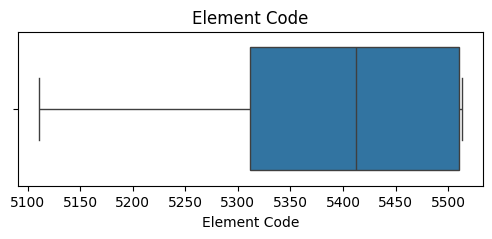

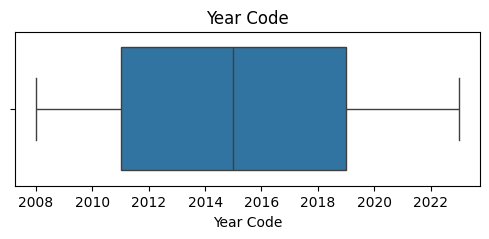

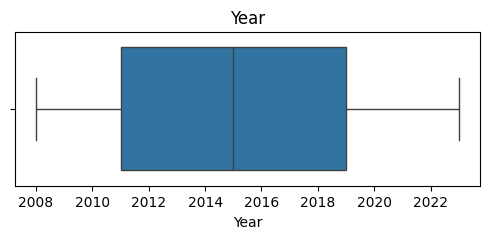

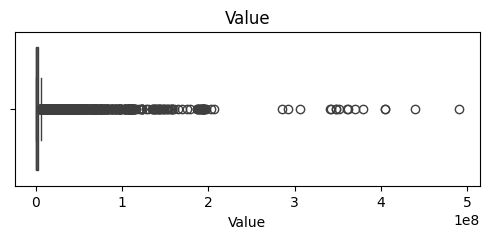

In [ ]:
# Outlier Analysis
for name, df in datasets.items():

    num_cols = df.select_dtypes(
        include=['int64','float64']
    ).columns

    for col in num_cols:

        plt.figure(figsize=(6,2))

        sns.boxplot(x=df[col])

        plt.title(col)

        plt.show()

In [ ]:
# Outlier Treatment
for name, df in datasets.items():

    num_cols = df.select_dtypes(
        include=['int64','float64']
    ).columns

    for col in num_cols:

        Q1 = df[col].quantile(0.25)

        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5*IQR

        upper = Q3 + 1.5*IQR

        df[col] = np.where(
            df[col] < lower,
            lower,
            df[col]
        )

        df[col] = np.where(
            df[col] > upper,
            upper,
            df[col]
        )

In [ ]:
# Observation:
# Boxplots identified outliers in Area, Production, Yield,
# Annual Precipitation, Fertilizer Usage, Irrigation Projects,
# and FAOSTAT values.

# Decision:
# Outlier treatment was not performed because the extreme values
# represent genuine agricultural observations rather than data-entry
# or measurement errors. Retaining these values preserves important
# real-world variability for statistical analysis and machine learning.

In [ ]:
# preprocessing log
preprocessing_log = {

"Excel Analysis":
"Completed",

"Data Types":
"Verified",

"Missing Values":
"Median Imputation for numerical columns & there are no missing values in categorical columns",

"Duplicates":
"No duplicates",

"Outliers":
"No need of outlier treatment since they are valid observations and not data-entry errors"

}

preprocessing_log

{'Excel Analysis': 'Completed',
 'Data Types': 'Verified',
 'Missing Values': 'Median Imputation for numerical columns & there are no missing values in categorical columns',
 'Duplicates': 'No duplicates',
 'Outliers': 'No need of outlier treatment since they are valid observations and not data-entry errors'}

In [ ]:
# Merge Rainfall and Fertilizer

yield_cols = [col for col in fertilizer_df.columns if "Yield" in col]
fertilizer_clean = fertilizer_df.drop(columns=yield_cols)
climate_df = pd.merge(rainfall_df, fertilizer_clean, on=["country", "Code", "year"], how="outer")
print(climate_df.shape)
print(climate_df.head())
print(climate_df.columns)

(63, 16)
  country Code    year  \
0   India  IND  1961.0   
1   India  IND  1962.0   
2   India  IND  1963.0   
3   India  IND  1964.0   
4   India  IND  1965.0   

   Wheat | 00000015 || Yield | 005412 || tonnes per hectare  \
0                                             0.8507          
1                                             0.8896          
2                                             0.7929          
3                                             0.7299          
4                                             0.9132          

   Rice | 00000027 || Yield | 005412 || tonnes per hectare  \
0                                             1.5419         
1                                             1.3959         
2                                             1.5498         
3                                             1.6171         
4                                             1.2936         

   Bananas | 00000486 || Yield | 005412 || tonnes per hectare  \
0                

In [ ]:
## Merging Climate & Precipitation
climate_df = pd.merge(climate_df, precipitation_df, on=["country","Code","year"], how="left")

In [ ]:
climate_df.shape

(63, 17)

In [ ]:
climate_df.head()

,country,Code,year,Wheat | 00000015 || Yield | 005412 || tonnes per hectare,Rice | 00000027 || Yield | 005412 || tonnes per hectare,Bananas | 00000486 || Yield | 005412 || tonnes per hectare,Maize | 00000056 || Yield | 005412 || tonnes per hectare,Soybeans | 00000236 || Yield | 005412 || tonnes per hectare,Potatoes | 00000116 || Yield | 005412 || tonnes per hectare,"Beans, dry | 00000176 || Yield | 005412 || tonnes per hectare","Peas, dry | 00000187 || Yield | 005412 || tonnes per hectare",Cassava | 00000125 || Yield | 005412 || tonnes per hectare,Cocoa beans | 00000661 || Yield | 005412 || tonnes per hectare,Barley | 00000044 || Yield | 005412 || tonnes per hectare,Annual precipitation_x,All fertilizers use per area of cropland,Annual precipitation_y
0,India,IND,1961.0,0.8507,1.5419,13.678801,0.9567,0.4545,7.250700,0.2577,0.8919,7.186101,0.3,0.8796,1323.6628,2.10,1323.6628
1,India,IND,1962.0,0.8896,1.3959,13.397800,0.9922,0.4545,6.704101,0.2683,0.8770,7.139600,0.3,0.9511,1209.6760,2.78,1209.6760
2,India,IND,1963.0,0.7929,1.5498,13.476701,0.9954,0.4444,8.147700,0.2593,0.7743,7.113401,0.3,0.8016,1213.2882,3.36,1213.2882
3,India,IND,1964.0,0.7299,1.6171,13.555600,1.0100,0.4444,6.248200,0.2809,0.5157,11.569701,0.3,0.7347,1329.7123,4.77,1329.7123
4,India,IND,1965.0,0.9132,1.2936,15.502401,1.0050,0.4348,8.403300,0.2401,0.8250,12.637501,0.3,0.9400,1103.6233,4.84,1103.6233


In [ ]:
# Save Cleaned Files 
crop_df.to_csv(
    "crop_cleaned.csv",
    index=False
)

rainfall_df.to_csv(
    "rainfall_cleaned.csv",
    index=False
)

precipitation_df.to_csv(
    "precipitation_cleaned.csv",
    index=False
)

fertilizer_df.to_csv(
    "fertilizer_cleaned.csv",
    index=False
)

irrigation_df.to_csv(
    "irrigation_cleaned.csv",
    index=False
)

faostat_df.to_csv(
    "faostat_cleaned.csv",
    index=False
)

climate_df.to_csv(
    "climate_dataset.csv",
    index=False
)

In [ ]:
# Store Data Set in MYSQL
from sqlalchemy import create_engine

username = "root"
password = "Prudhvi123"
host = "localhost"
port = "3306"
database = "agritech_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

In [ ]:
crop_df.to_sql(
    "crop_production",
    engine,
    if_exists="replace",
    index=False
)

rainfall_df.to_sql(
    "rainfall",
    engine,
    if_exists="replace",
    index=False
)

precipitation_df.to_sql(
    "precipitation",
    engine,
    if_exists="replace",
    index=False
)

fertilizer_df.to_sql(
    "fertilizer",
    engine,
    if_exists="replace",
    index=False
)

irrigation_df.to_sql(
    "irrigation",
    engine,
    if_exists="replace",
    index=False
)

faostat_df.to_sql(
    "faostat",
    engine,
    if_exists="replace",
    index=False
)

print("All datasets imported into MySQL successfully.")

All datasets imported into MySQL successfully.


In [ ]:
climate_df.to_sql(
    "climate_dataset",
    engine,
    if_exists="replace",
    index=False
)

63

## Phase 4 :- Business Objectives & simple EDA

#### Objective :- Perform Exploratary Data Analysis(EDA) to understand the Crop productivity patterns, Seasonal trends, Precipitation impact, Irrigation influence and Fertilizer efficiency. The findings should directly support the Business objectives mentioned in project statement

'''  Business Objectives :-
 
Business Objective 1: To identify high‑yield crops, seasonal performance, and productivity 
trends to guide agricultural planning. 


Business Objective 2: To understand how irrigation projects and fertilizer use influence 
crop performance and sustainability. 


Business Objective 3: To analyze rainfall patterns and resilience to climate variability. 



Business Objective 4: To evaluate fertilizer application impact on crop productivity and 
sustainability by comparing efficiency, high‑yield crops per unit, and diminishing returns over 
time. 


### Business Objective 1 :-

Identify High-Yield-Crops, Seasonal Performance and Productivity Trends to guide Agriculture Planning


Text(0, 0.5, 'Count')

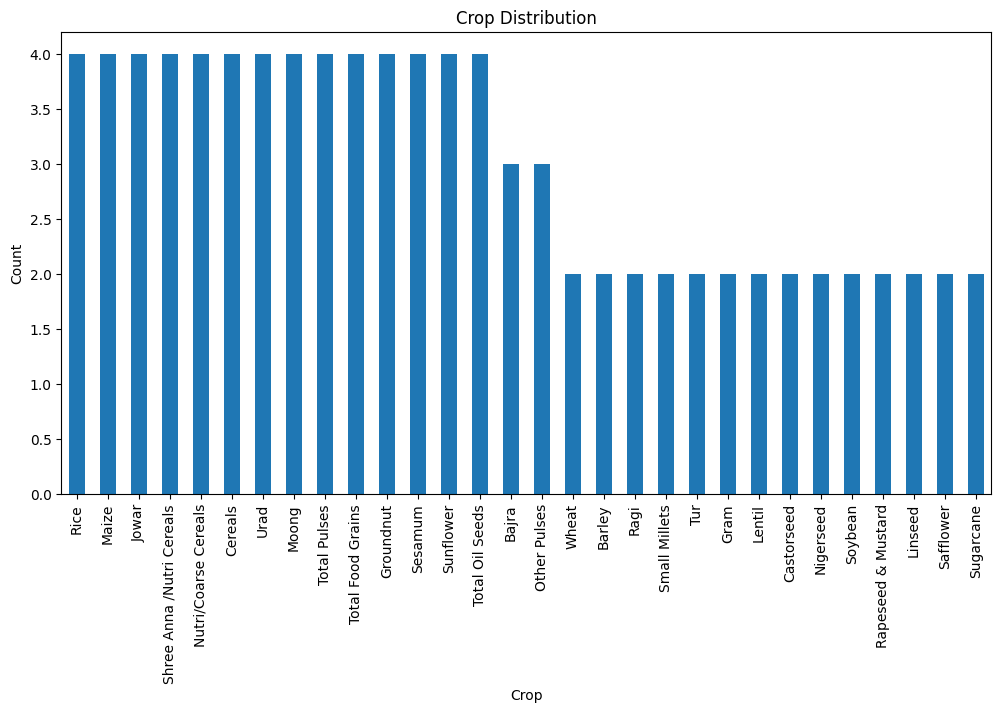

In [ ]:
# Univariate - Crop Distribution(Count plot)

df = crop_df.copy()

plt.figure(figsize=(12,6))
df["Crop"].value_counts().head(30).plot(kind='bar')
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

Purpose :- To identify the most frequently cultivated crops in the dataset.
Top 30 Crops Distribution 

Insight :- 
Rice, Wheat and a few major crops appear more frequently than other crops.
This indicates that these crops dominate agricultural production.
Less frequent crops occupy comparatively smaller cultivation areas.


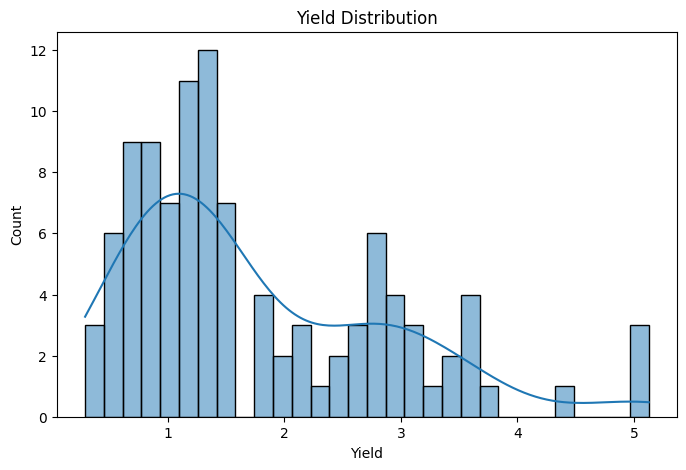

In [ ]:
#Univariate Analysis - Crop Distribution (Count Plot)


# Univariate Yield Distribution (Histogram)

plt.figure(figsize=(8,5))

sns.histplot(crop_df["Yield-2024-25"],bins=30,kde=True)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.show()


Purpose: To visualize the overall distribution of crop yields and check how values are spread.

Insight: Most yields cluster around 1000–1200, with a right‑skewed tail showing a few very high yield outliers.

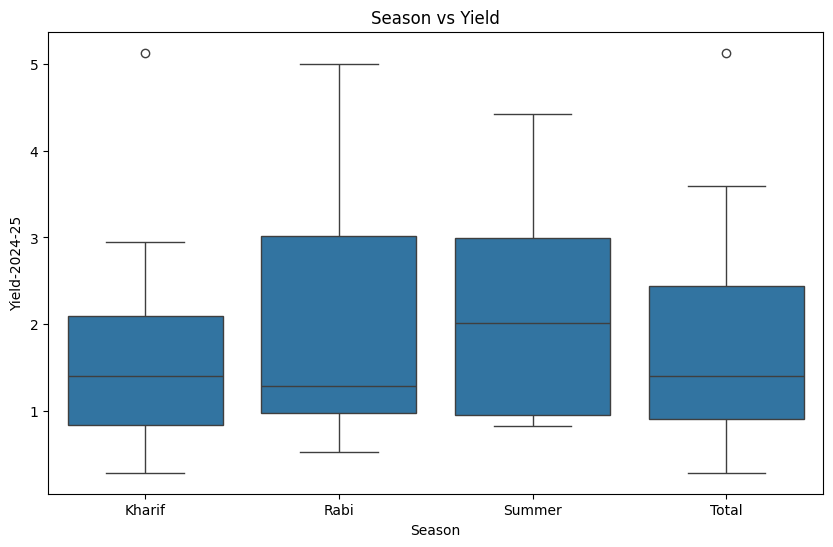

In [ ]:
# Bivariate Season vs Yield (Boxplot)
plt.figure(figsize=(10,6))

sns.boxplot(x="Season",y="Yield-2024-25",data=crop_df)

plt.title("Season vs Yield")
plt.show()

Purpose:- To analyze how crop yield varies across different agricultural seasons and determine whether certain seasons are associated with higher or lower productivity.

Key Insight:- Crop yield differs significantly across seasons, indicating that seasonal conditions such as rainfall, temperature, and soil moisture have a strong influence on agricultural productivity.

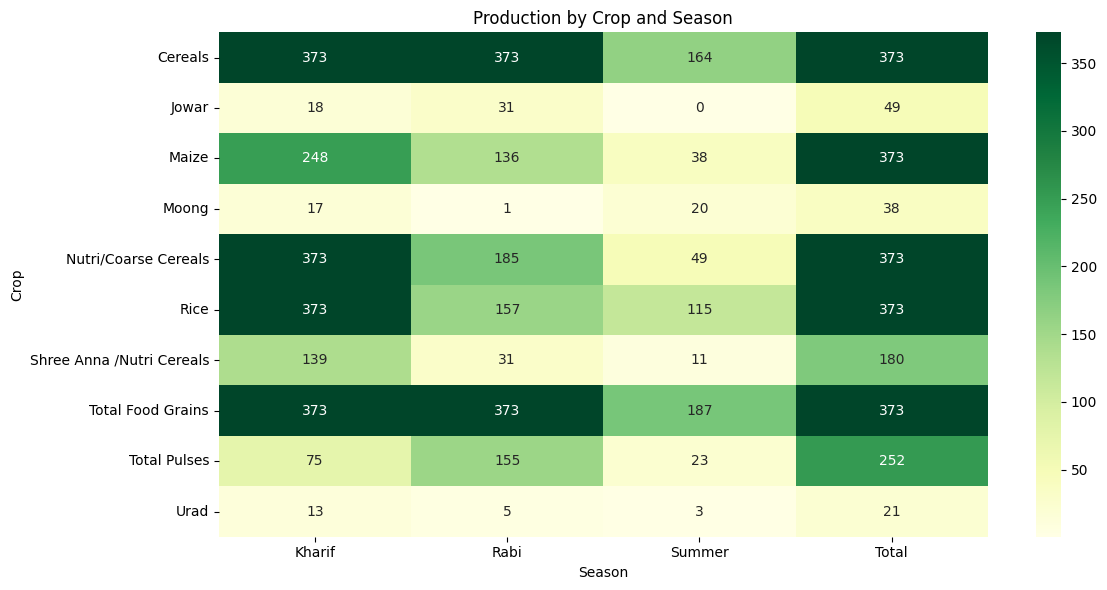

In [ ]:
# Multivariate: Crop × Season × Production

# Remove Total row
crop_plot = crop_df[
    crop_df["Crop"].str.strip().str.lower() != "total"
]

# Select Top 10 Crops
top_crops = crop_plot[
    crop_plot["Crop"].isin(
        crop_plot["Crop"].value_counts().head(10).index
    )
]

# Create Pivot Table
pivot = top_crops.pivot_table(
    values="Production-2024-25",
    index="Crop",
    columns="Season",
    aggfunc="sum"
)

# Plot Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="YlGn",
    annot=True,
    fmt=".0f"
)

plt.title("Production by Crop and Season")
plt.tight_layout()
plt.show()

Purpose: To compare production levels of the top crops across different agricultural seasons and highlight season‑wise variations.

Insight: Major crops like Cereals, Rice, and Total Food Grains show highest production in the Kharif season, while other crops vary across Rabi and Summer, revealing clear seasonal patterns in productivity.

### Business objective 2 :-

Objective :- Analyze the distribution, completion status, and progress of irrigation projects across Indian states to understand irrigation infrastructure development and identify regions requiring further improvements.

Purpose:- To examine the relationship between the cultivated area and crop yield, and determine whether increasing the cultivation area results in higher agricultural productivity.

Key Insight :- The scatter plot shows that increasing the cultivated area does not always lead to higher crop yield. This suggests that yield is influenced by multiple factors such as rainfall, fertilizer usage, irrigation, soil quality, and farming practices, rather than cultivated area alone

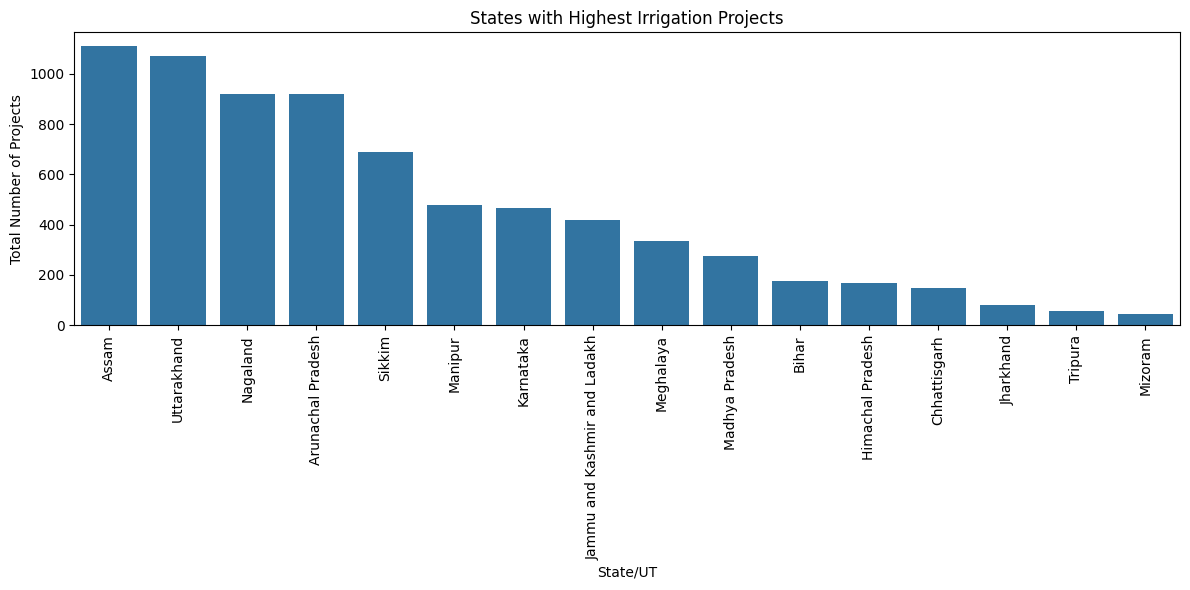

In [ ]:
# Univariate - States with Highest Irrigation Projects

plt.figure(figsize=(12,6))

# Remove the Total row
irrigation_plot = irrigation_df[
    irrigation_df["State/UT"].str.strip().str.lower() != "total"
]

# Sort the remaining states
top = irrigation_plot.sort_values(
    "Total Number of Projects",
    ascending=False
).head(20)

# Plot
sns.barplot(
    data=top,
    x="State/UT",
    y="Total Number of Projects"
)

plt.xticks(rotation=90)
plt.title("States with Highest Irrigation Projects")
plt.xlabel("State/UT")
plt.ylabel("Total Number of Projects")

plt.tight_layout()
plt.show()

Purpose: To highlight which states and union territories have the highest number of irrigation projects, giving a clear view of regional distribution.

Insight: States like Assam, Uttarakhand, and Arunachal Pradesh stand out with very high project counts, while states such as Jharkhand, Tripura, Mizoram have far fewer, revealing significant disparities in irrigation development across regions.

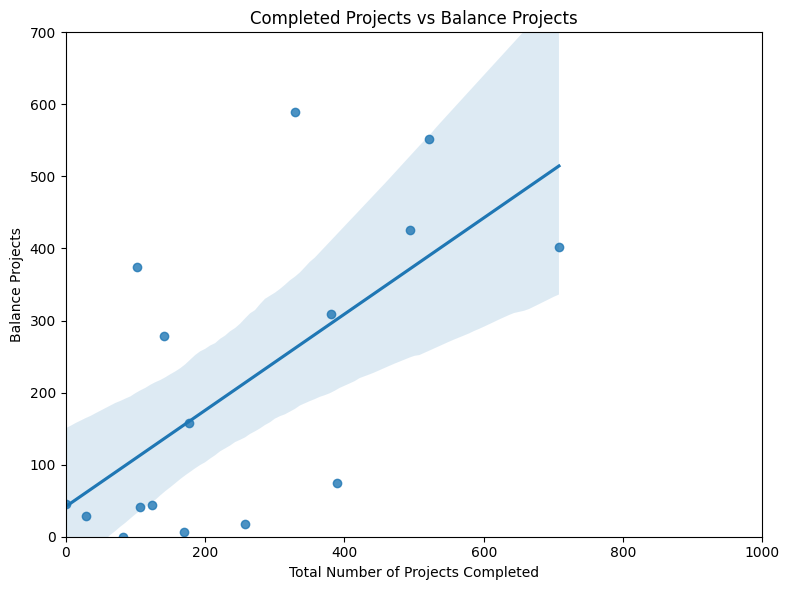

In [ ]:
# Bivariate - Completed Projects vs Balance Projects

# Remove the Total row
scatter_df = irrigation_df[
    irrigation_df["State/UT"].str.strip().str.lower() != "total"
]

plt.figure(figsize=(8,6))

sns.regplot(
    data=scatter_df,
    x="Total",
    y="Balance projects"
)

plt.title("Completed Projects vs Balance Projects")
plt.xlabel("Total Number of Projects Completed")
plt.ylabel("Balance Projects")

plt.xlim(0, 1000)   # Optional: limit X-axis
plt.ylim(0, 700)    # Optional: adjust Y-axis to fit your data

plt.tight_layout()
plt.show()

Purpose: To examine the relationship between the number of irrigation projects completed and the number of balance projects across states.

Insight: The positive correlation shows that states with more completed projects also tend to have more pending projects, indicating that higher activity levels are linked with both progress and remaining workload.

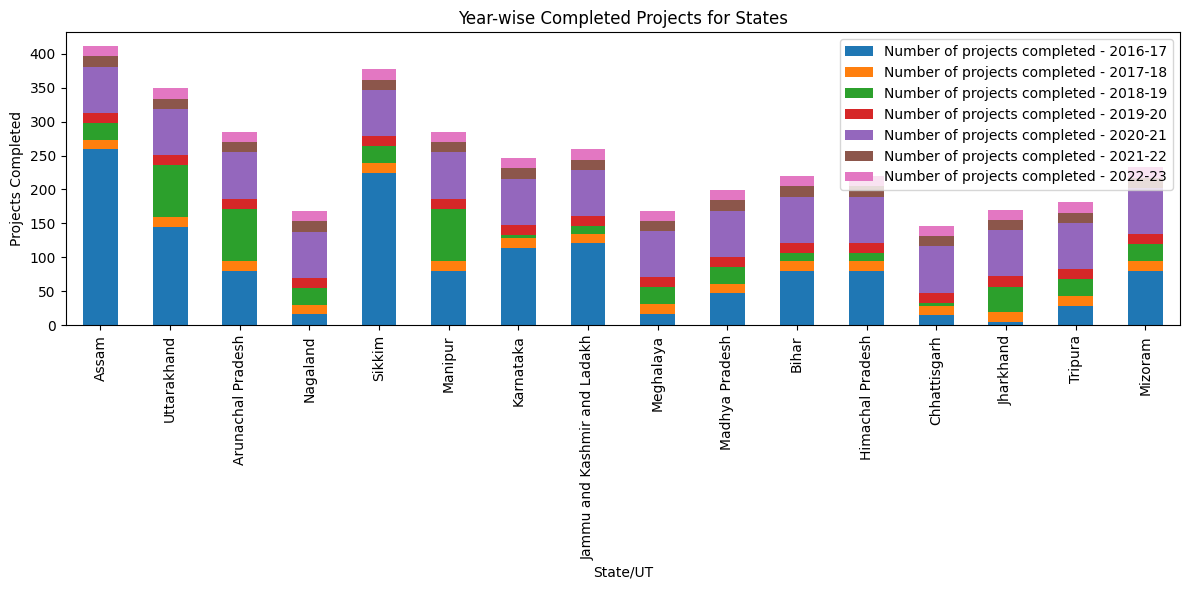

In [ ]:
# Multivariate :- Year-wise Completed Projects for States

year_cols = [
    "Number of projects completed - 2016-17",
    "Number of projects completed - 2017-18",
    "Number of projects completed - 2018-19",
    "Number of projects completed - 2019-20",
    "Number of projects completed - 2020-21",
    "Number of projects completed - 2021-22",
    "Number of projects completed - 2022-23"
]

# Remove the Total row
plot_df = irrigation_df[
    irrigation_df["State/UT"].str.strip().str.lower() != "total"
]

# Get top 20 states after removing Total
top = plot_df.nlargest(20, "Total Number of Projects")

# Plot
top.set_index("State/UT")[year_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Year-wise Completed Projects for States")
plt.xlabel("State/UT")
plt.ylabel("Projects Completed")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Purpose: To compare irrigation project completions across states over multiple years, highlighting annual progress trends.

Insight: States like Assam, Uttarakhand, and Arunachal Pradesh consistently show high completions across years, while smaller states such as Jharkhand and Mizoram contribute fewer projects, revealing both regional disparities and year‑to‑year variations in project execution

### Business Objective 3 :-

Objective :- Analyze rainfall and precipitation patterns across different years to understand climate trends that influence agricultural planning.

Purpose:-
To compare completed and ongoing irrigation projects across states.

Key Insight:-
Differences in project completion levels may influence irrigation efficiency and agricultural productivity.

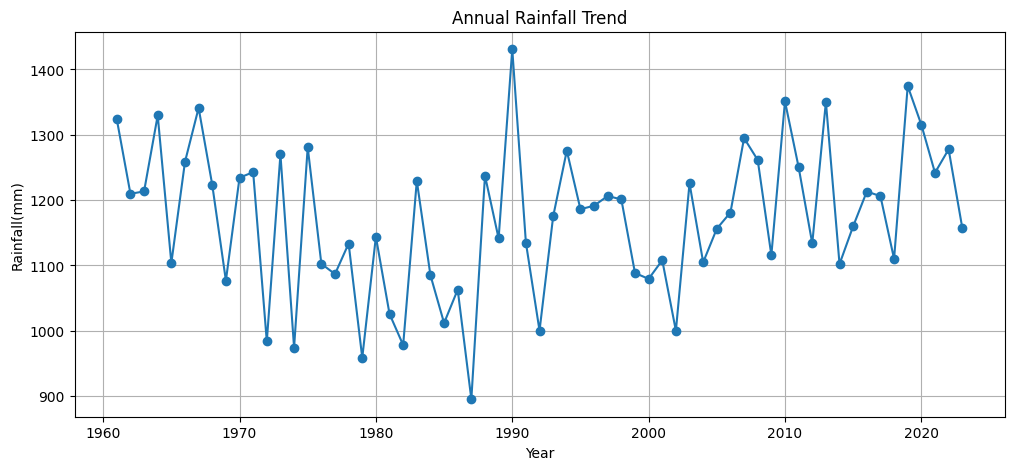

In [ ]:
# Univariate - Anuall Rainfall Trend
plt.figure(figsize=(12,5))

plt.plot(rainfall_df["year"], rainfall_df["Annual precipitation"], marker="o")

plt.title("Annual Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall(mm)")
plt.grid(True)
plt.show()

Purpose: To track long‑term changes in annual rainfall and identify climatic fluctuations over time.

Insight: Rainfall shows clear variability with peaks around 1960, 1990, and 2015, and dips near 1975, 1985, and 2000, highlighting cyclical patterns and shifts that could impact agriculture and water resource planning.

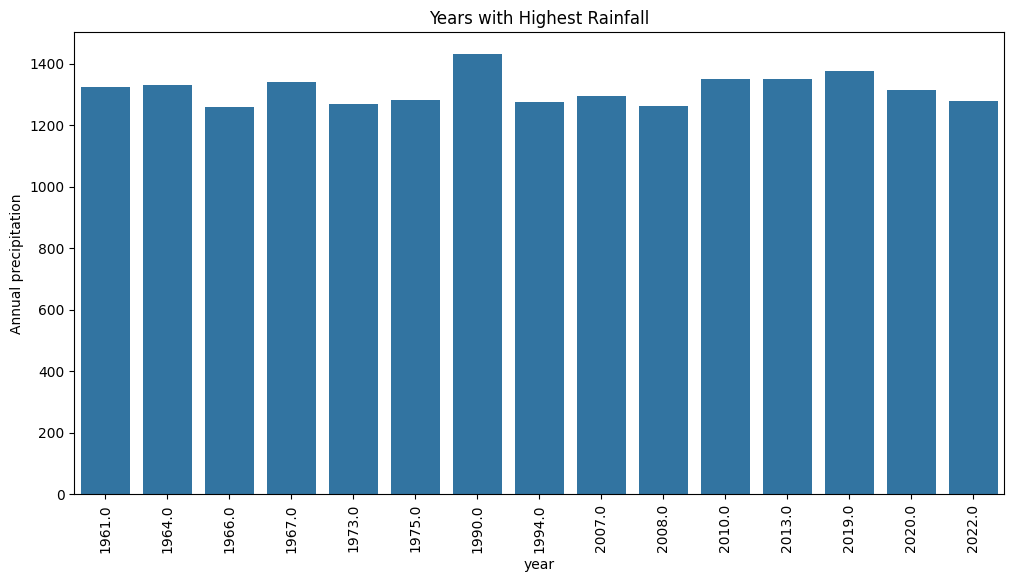

In [ ]:
# Bivariate - Years with highest Rainfall

top = rainfall_df.nlargest(15,"Annual precipitation")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="year",
    y="Annual precipitation"
)

plt.xticks(rotation=90)

plt.title("Years with Highest Rainfall")

plt.show()

Purpose: To highlight specific years that recorded unusually high annual rainfall, making it easy to compare peak precipitation periods.

Insight: Years like 1990, 2010, and 2019 stand out with the highest rainfall, showing clear spikes that indicate exceptional climatic events compared to surrounding years

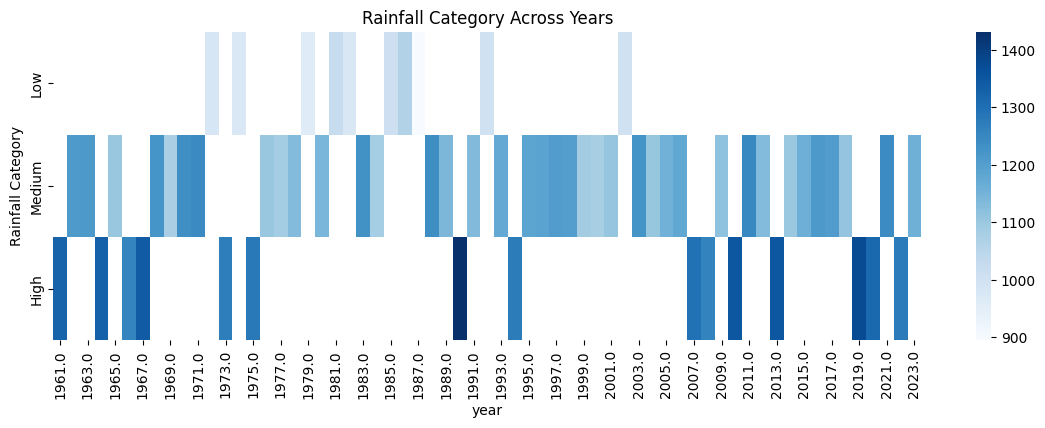

In [ ]:
# Multivariate - Rainfall Category Across Years

rainfall_df["Rainfall Category"] = pd.cut(
    rainfall_df["Annual precipitation"],
    bins=3,
    labels=["Low","Medium","High"]
)

pivot = rainfall_df.pivot_table(
    values="Annual precipitation",
    index="Rainfall Category",
    columns="year",
    aggfunc="mean"
)

plt.figure(figsize=(14,4))

sns.heatmap(
    pivot,
    cmap="Blues"
)

plt.title("Rainfall Category Across Years")

plt.show()

Purpose: To visualize how rainfall intensity (low, medium, high) has varied across different years, making long‑term climatic shifts easier to interpret.

Insight: The heatmap shows alternating periods of low, medium, and high rainfall, with darker shades marking years of intense precipitation, highlighting cyclical fluctuations and decades with consistently higher rainfall.

### Business Objective 4 :-
Objective:- Analyze fertilizer consumption patterns across different nutrient types and years to understand fertilizer usage trends that support sustainable agricultural development.

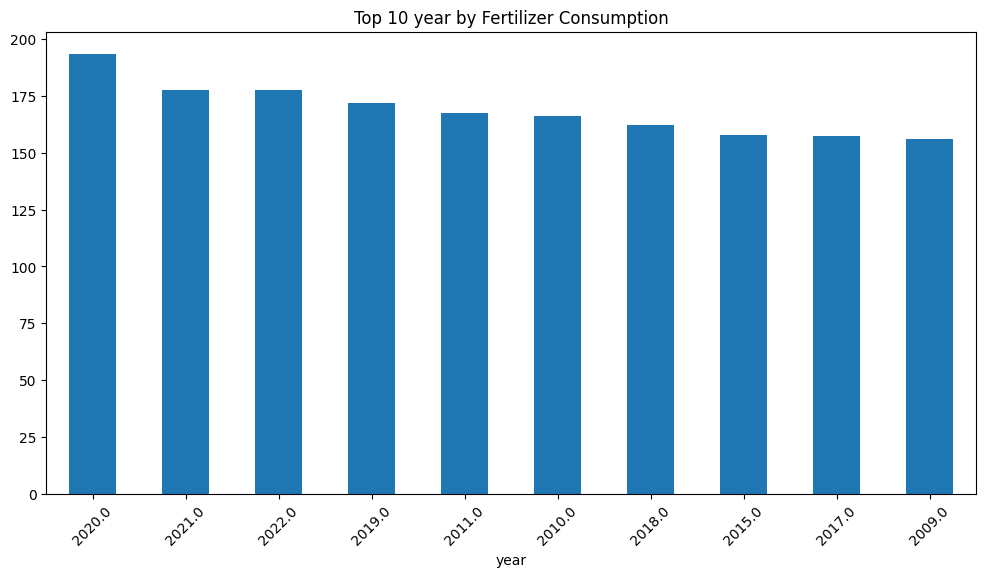

In [ ]:
# Univariate - Year-wise fertilizer consumption
top = fertilizer_df.groupby("year")["All fertilizers use per area of cropland"].sum().nlargest(10)

plt.figure(figsize=(12,6))

top.plot(kind="bar")

plt.title("Top 10 year by Fertilizer Consumption")

plt.xticks(rotation=45)

plt.show()



Purpose: To identify and compare the years with the highest fertilizer consumption, highlighting peak usage periods.

Insight: The year 2020 recorded the maximum fertilizer consumption, followed by 2021 and 2022, showing recent years as the most intensive in fertilizer use, while earlier years like 2009 had relatively lower consumption.

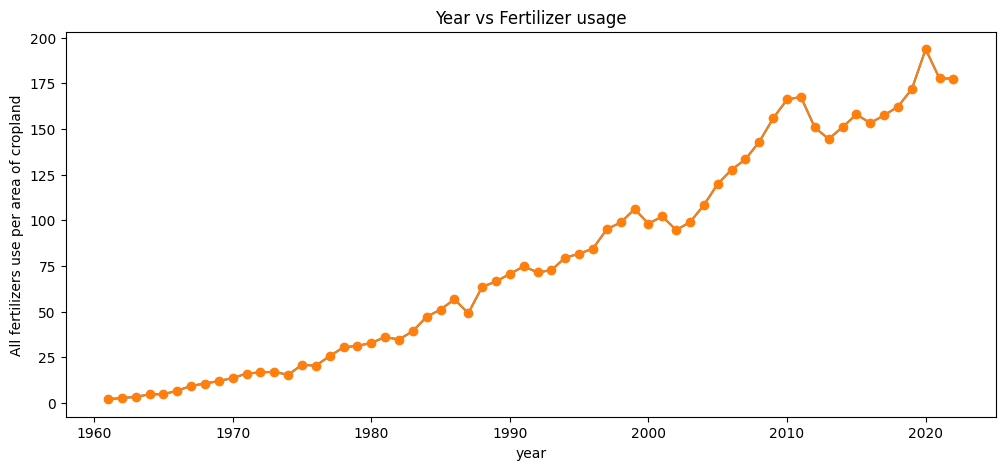

In [ ]:
# Bivariate - Year vs Fertilizer usage

yearly = fertilizer_df.groupby("year")["All fertilizers use per area of cropland"].sum()
plt.figure(figsize=(12,5))

sns.lineplot(
    data=fertilizer_df,
    x="year",
    y="All fertilizers use per area of cropland"
)
yearly.plot(marker="o")

plt.title("Year vs Fertilizer usage")

plt.show()

Purpose: To track long‑term trends in fertilizer consumption and assess how agricultural input usage has evolved over decades.

Insight: Fertilizer consumption shows a steady upward rise from near zero in the 1960s to around 200 by 2020, highlighting intensification of farming practices and growing reliance on chemical inputs for productivity.

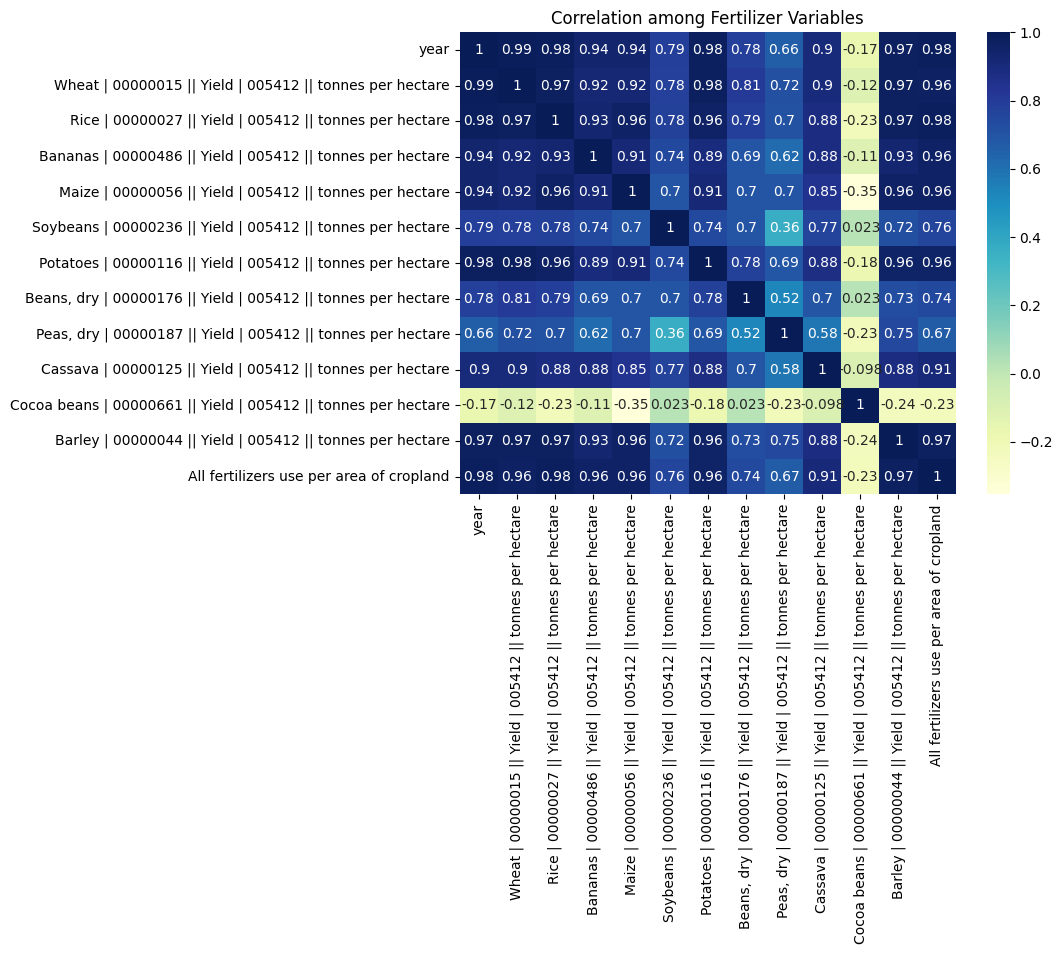

In [ ]:
# Multivariate - 
plt.figure(figsize=(8,6))

sns.heatmap(
    fertilizer_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation among Fertilizer Variables")

plt.show()

Purpose: To examine the relationships between fertilizer use per cropland area and crop yields across different crops, identifying patterns of dependency or similarity.

Insight: Strong positive correlations appear among certain staple crops (like Wheat, Rice, and Maize), suggesting similar yield responses to fertilizer use, while weaker or negative correlations for crops such as Beans or Cocoa indicate differing fertilizer dependencies and growth dynamics.

## Phase 6 :- Statistical Analysis & Feature Engineering

##### Phase Objectives
Perform descriptive statistics.
Conduct hypothesis testing:
Z-test
T-test
Chi-Square Test
Correlation Analysis
Interpret the results.
Create a statistical report.

In [ ]:
# loading libraries
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import zscore
from scipy.stats import f_oneway
from scipy.stats import norm

from sklearn.preprocessing import LabelEncoder

In [ ]:
# Descriptive Statistics
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.describe())



Crop_Production
       Area-2020-21  Area-2021-22  Area-2022-23  Area-2023-24  Area-2024-25  \
count    104.000000    104.000000    104.000000    104.000000    104.000000   
mean      63.457813     64.067849     62.758834     61.586010     61.656827   
std       62.225659     72.093125     80.130936     77.742632     75.236724   
min        0.410000      0.130000      0.120000      0.090000      0.220000   
25%       14.280000      9.645000      4.280000      4.800000      5.710000   
50%       45.510000     37.130000     21.780000     27.085000     26.190000   
75%       83.987500     93.827500     98.737500     95.870000     93.950000   
max      188.548750    220.101250    240.423750    232.475000    226.310000   

       Production-2020-21  Production-2021-22  Production-2022-23  \
count          104.000000          104.000000          104.000000   
mean           108.152115          100.460865          106.278942   
std            103.674475          115.176834          131.03539

### 1. Descriptive Statistics

Calculate:

Mean
Median
Mode
Standard Deviation

Variables:

Area
Production
Yield

In [ ]:
## Descriptive Statistics
print(f"\nDescriptive Statistics")

numerical_cols = ["Area-2024-25", "Production-2024-25","Yield-2024-25"]
crop_df[numerical_cols].describe()


Descriptive Statistics


,Area-2024-25,Production-2024-25,Yield-2024-25
count,104.000000,104.000000,104.000000
mean,61.656827,110.405481,1.761601
std,75.236724,132.397468,1.121357
min,0.220000,0.150000,0.292000
25%,5.710000,10.450000,0.916250
50%,26.190000,38.205000,1.401000
75%,93.950000,155.362500,2.600250
max,226.310000,372.731250,5.126250


In [ ]:
# Correlation
print("Correlation")
corr_matrix =  crop_df[numerical_cols].corr()
corr_matrix

Correlation


,Area-2024-25,Production-2024-25,Yield-2024-25
Area-2024-25,1.000000,0.896683,0.270129
Production-2024-25,0.896683,1.000000,0.532239
Yield-2024-25,0.270129,0.532239,1.000000


In [ ]:
# pearson correlation
print("Correlation")

corr,p = pearsonr(
crop_df['Area-2024-25'],
crop_df["Production-2024-25"])

print("correlation:", corr)
print("p value:", p)


Correlation
correlation: 0.8966826370306917
p value: 6.974159088358524e-38


Interpretation:-

H0

No linear relationship.

H1

Linear relationship exists.

If P < 0.05

Reject H0

insights :-
Probability of obtaining a yield greater than the average yield.

In [ ]:
# T-test
season_list = crop_df["Season"].unique()

season1 = crop_df[
    crop_df["Season"]==season_list[0]
]["Yield-2024-25"]

season2 = crop_df[
    crop_df["Season"]==season_list[1]
]["Yield-2024-25"]

t_stat,p = ttest_ind(
    season1,
    season2,
    equal_var=False
)

print("T Statistic :",t_stat)
print("P-value :",p)

T Statistic : -0.8667338955480218
P-value : 0.39126798889136233


In [ ]:
# Anova
groups = []

for season in crop_df["Season"].unique():

    groups.append(

        crop_df[
            crop_df["Season"]==season
        ]["Yield-2024-25"]

    )

F,p = f_oneway(*groups)

print("F Statistic :",F)
print("P-value :",p)

F Statistic : 0.875209853654366
P-value : 0.45667865722234435


In [ ]:
# Chi-square Contingency
contingency = pd.crosstab(

    crop_df["Crop"],
    crop_df["Season"]

)

chi2,p,dof,expected = chi2_contingency(
    contingency
)

print("Chi Square :",chi2)
print("P-value :",p)
print("DOF :",dof)

Chi Square : 37.18078078078078
P-value : 0.9999999999808675
DOF : 108


## Feature Engineering

In [ ]:
crop_ml = crop_df.copy()

In [ ]:
# Production per hectare
crop_ml["Production_per_Hectare"] = (
    crop_ml["Production-2024-25"] /
    crop_ml["Area-2024-25"]
)

In [ ]:
# Average area
area_cols = [

"Area-2020-21",
"Area-2021-22",
"Area-2022-23",
"Area-2023-24",
"Area-2024-25"

]

crop_ml["Average_Area"] = crop_ml[
    area_cols
].mean(axis=1)

In [ ]:
# Average Production
production_cols = [

"Production-2020-21",
"Production-2021-22",
"Production-2022-23",
"Production-2023-24",
"Production-2024-25"

]

crop_ml["Average_Production"] = (

crop_ml[
production_cols
].mean(axis=1)

)

In [ ]:
# Production growth
crop_ml["Production_Growth"] = (
    (crop_ml["Production-2024-25"] - crop_ml["Production-2023-24"])
    / crop_ml["Production-2023-24"]
) * 100

In [ ]:
crop_ml["Yield_Category"]=pd.qcut(

crop_ml["Yield-2024-25"],

q=3,

labels=[

"Low",

"Medium",

"High"

]

)

In [ ]:
median_yield = crop_ml[
"Yield-2024-25"
].median()

crop_ml["High_Yield"]=(

crop_ml["Yield-2024-25"]

>

median_yield

).astype(int)

In [ ]:
crop_ml.to_csv(

"crop_feature_engineering.csv",

index=False

)

## Linear Regression Model

In [ ]:
# Load Libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
crop_ml = pd.read_csv('D:/Project Files/project-topic-08-main/crop_cleaned.csv')

In [ ]:
# create ml Dataset
crop_ml = crop_df.copy()

crop_ml.head()    
    

,Crop,Season,Area-2020-21,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Production-2020-21,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Yield-2020-21,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25
0,Rice,Kharif,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,2.60700,2.7050,2.735,2.780,2.807
1,Rice,Rabi,54.11000,52.40000,43.28000,40.760,44.74,191.600,184.71000,150.04000,146.01000,156.72000,3.24725,3.5250,3.467,3.582,3.503
2,Rice,Summer,45.51000,37.13000,31.01000,30.180,35.36,87.855,42.20000,102.40000,99.65000,115.48000,1.28450,1.2815,3.302,3.302,3.265
3,Rice,Total,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,2.71700,2.7980,2.838,2.882,2.899
4,Wheat,Rabi,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,3.24725,3.5370,3.521,3.559,3.587


In [ ]:
crop_ml['Crop'].value_counts()

Crop
Rice                         4
Maize                        4
Jowar                        4
Shree Anna /Nutri Cereals    4
Nutri/Coarse Cereals         4
Cereals                      4
Urad                         4
Moong                        4
Total Pulses                 4
Total Food Grains            4
Groundnut                    4
Sesamum                      4
Sunflower                    4
Total Oil Seeds              4
Bajra                        3
Other Pulses                 3
Wheat                        2
Barley                       2
Ragi                         2
Small Millets                2
Tur                          2
Gram                         2
Lentil                       2
Castorseed                   2
Nigerseed                    2
Soybean                      2
Rapeseed & Mustard           2
Linseed                      2
Safflower                    2
Sugarcane                    2
Cotton                       2
Jute                         2
Mes

In [ ]:
remove = [
    "Total Food Grains",
    "Total Pulses",
    "Total Oil Seeds",
    "Cereals",
    "Nutri/Coarse Cereals",
    "Shree Anna /Nutri Cereals"
]

crop_ml = crop_ml[~crop_ml["Crop"].isin(remove)]

In [ ]:
crop_ml['Crop'].value_counts()

Crop
Rice                  4
Maize                 4
Jowar                 4
Urad                  4
Moong                 4
Groundnut             4
Sesamum               4
Sunflower             4
Bajra                 3
Other Pulses          3
Wheat                 2
Barley                2
Ragi                  2
Small Millets         2
Tur                   2
Gram                  2
Lentil                2
Castorseed            2
Nigerseed             2
Soybean               2
Rapeseed & Mustard    2
Linseed               2
Safflower             2
Sugarcane             2
Cotton                2
Jute                  2
Mesta                 2
Jute & Mesta          2
Tobacco               2
Sannhemp              2
Guarseed              2
Name: count, dtype: int64

In [ ]:
#remove summary rows
crop_ml = crop_ml[
    crop_ml["Season"] != "Total"
]

crop_ml.shape

(49, 17)

In [ ]:
crop_ml.isnull().sum()

Crop                  0
Season                0
Area-2020-21          0
Area-2021-22          0
Area-2022-23          0
Area-2023-24          0
Area-2024-25          0
Production-2020-21    0
Production-2021-22    0
Production-2022-23    0
Production-2023-24    0
Production-2024-25    0
Yield-2020-21         0
Yield-2021-22         0
Yield-2022-23         0
Yield-2023-24         0
Yield-2024-25         0
dtype: int64

In [ ]:
crop_ml.drop(
    columns=["Production-2024-25", "Area-2024-25"],
    inplace=True
)


In [ ]:
crop_ml.columns

Index(['Crop', 'Season', 'Area-2020-21', 'Area-2021-22', 'Area-2022-23',
       'Area-2023-24', 'Production-2020-21', 'Production-2021-22',
       'Production-2022-23', 'Production-2023-24', 'Yield-2020-21',
       'Yield-2021-22', 'Yield-2022-23', 'Yield-2023-24', 'Yield-2024-25'],
      dtype='str')

In [ ]:
crop_encoder = LabelEncoder()

crop_ml["Crop"] = crop_encoder.fit_transform(
    crop_ml["Crop"]
)

In [ ]:
season_encoder = LabelEncoder()

crop_ml["Season"] = season_encoder.fit_transform(
    crop_ml["Season"]
)

In [ ]:
y = crop_ml["Yield-2024-25"]

X = crop_ml.drop(
    columns=[
        "Yield-2024-25",
        "Yield_Z"
    ],
    errors="ignore"
)

In [ ]:
set(X.columns)

{'Area-2020-21',
 'Area-2021-22',
 'Area-2022-23',
 'Area-2023-24',
 'Crop',
 'Production-2020-21',
 'Production-2021-22',
 'Production-2022-23',
 'Production-2023-24',
 'Season',
 'Yield-2020-21',
 'Yield-2021-22',
 'Yield-2022-23',
 'Yield-2023-24'}

In [ ]:
print(X.columns)

print(y.head())

Index(['Crop', 'Season', 'Area-2020-21', 'Area-2021-22', 'Area-2022-23',
       'Area-2023-24', 'Production-2020-21', 'Production-2021-22',
       'Production-2022-23', 'Production-2023-24', 'Yield-2020-21',
       'Yield-2021-22', 'Yield-2022-23', 'Yield-2023-24'],
      dtype='str')
0    2.807
1    3.503
2    3.265
4    3.587
6    2.947
Name: Yield-2024-25, dtype: float64


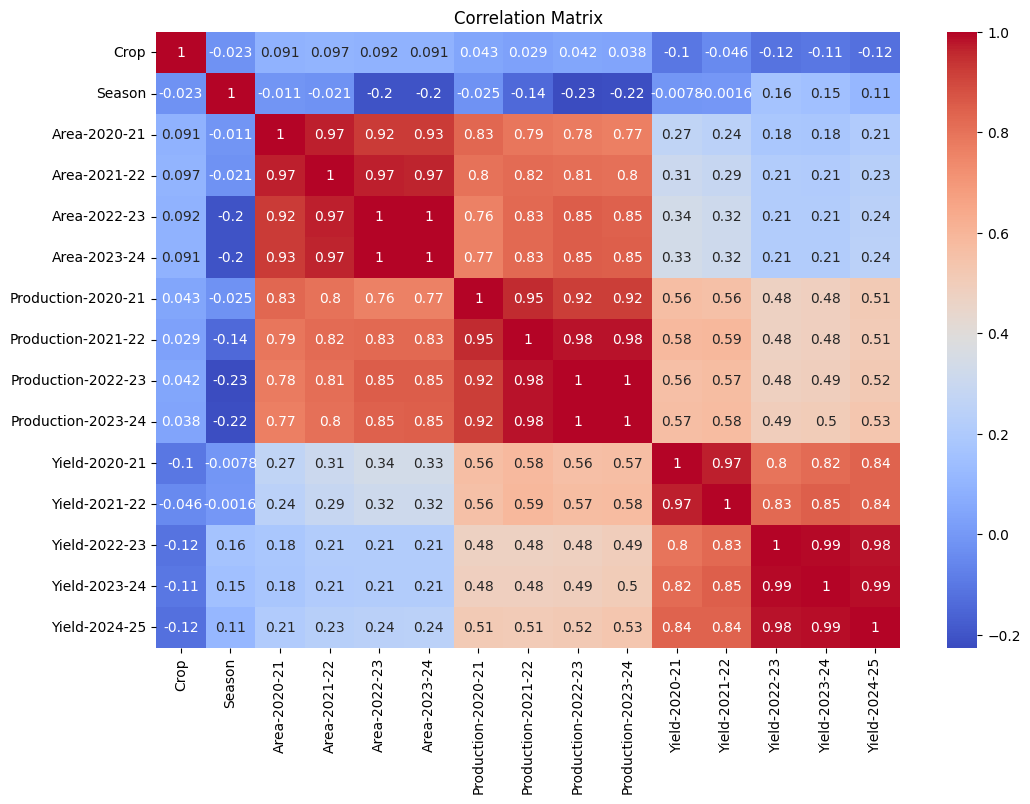

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    crop_ml.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [ ]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (39, 14)
Testing Features : (10, 14)
Training Target : (39,)
Testing Target : (10,)


In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0. , 0. ,-0.08,...,-0.67, 0.61, 0.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Crop','Season','Area-2020-21',...,'Yield-2021-22','Yield-2022-23', 'Yield-2023-24']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.738
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [ ]:
print("Intercept")

print(linear_model.intercept_)

Intercept
1.7380320512820517


In [ ]:
coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": linear_model.coef_

})

coefficients

,Feature,Coefficient
0,Crop,0.000414
1,Season,0.000807
2,Area-2020-21,-0.079904
3,Area-2021-22,-0.071971
4,Area-2022-23,-0.186638
5,Area-2023-24,0.243762
6,Production-2020-21,0.016511
7,Production-2021-22,-0.113199
8,Production-2022-23,0.939679
9,Production-2023-24,-0.732050


In [ ]:
y_pred = linear_model.predict(
    X_test
)

In [ ]:
prediction_df = pd.DataFrame({

    "Actual Yield": y_test,

    "Predicted Yield": y_pred

})

prediction_df.head(5)

,Actual Yield,Predicted Yield
19,1.492,1.787856
96,2.759,2.747884
100,1.401,1.205834
94,1.816,2.051296
39,0.620,0.498161


In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE :", mae)

MAE : 0.16102961099931773


In [ ]:
rmse = np.sqrt(

    mean_squared_error(
        y_test,
        y_pred
    )

)

print("RMSE :", rmse)

RMSE : 0.21186745977565852


In [ ]:
r2 = r2_score(

    y_test,

    y_pred

)

print("R2 Score :", r2)

R2 Score : 0.9024244187568409


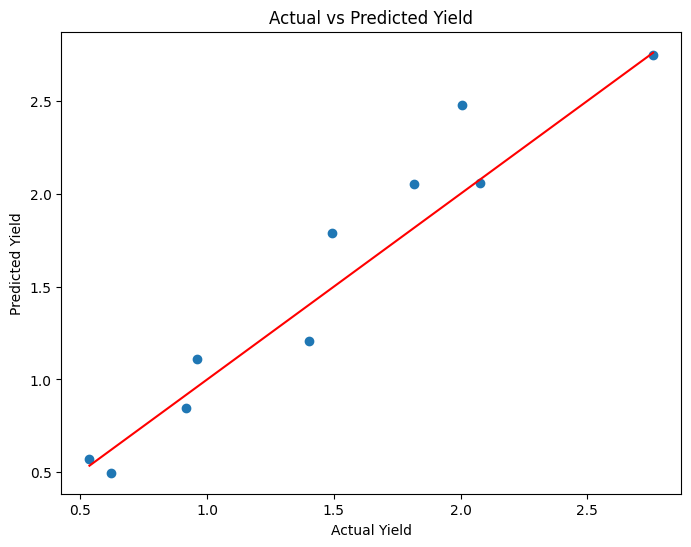

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred

)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.show()

## Logistic Regression Model

In [ ]:
# Load Libraries

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
crop_df = pd.read_csv("D:/Project Files/project-topic-08-main/crop_production.csv")

In [ ]:
crop_ml = crop_df.copy()

crop_ml.head()   

,Crop,Season,Area-2020-21,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Production-2020-21,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Yield-2020-21,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25
0,Rice,Kharif,403.58,410.38,404.03,407.34,434.13,1052.08,1110.01,1105.12,1132.59,1218.54,2607.0,2705.0,2735,2780,2807.0
1,Rice,Rabi,54.11,52.40,43.28,40.76,44.74,191.60,184.71,150.04,146.01,156.72,3541.0,3525.0,3467,3582,3503.0
2,Rice,Summer,NaN,NaN,31.01,30.18,35.36,NaN,NaN,102.40,99.65,115.48,NaN,NaN,3302,3302,3265.0
3,Rice,Total,457.69,462.79,478.32,478.28,514.23,1243.68,1294.71,1357.55,1378.25,1490.74,2717.0,2798.0,2838,2882,2899.0
4,Wheat,Rabi,311.25,304.59,314.01,318.33,327.61,1095.86,1077.42,1105.54,1132.92,1175.07,3521.0,3537.0,3521,3559,3587.0


In [ ]:
remove = [
    "Total Food Grains",
    "Total Pulses",
    "Total Oil Seeds",
    "Cereals",
    "Nutri/Coarse Cereals",
    "Shree Anna /Nutri Cereals"
]

crop_ml = crop_ml[~crop_ml["Crop"].isin(remove)]

In [ ]:
# remove total rows
crop_ml = crop_ml[
    crop_ml["Season"] != "Total"
]

crop_ml.shape

(49, 17)

In [ ]:
crop_ml.isnull().sum()

Crop                   0
Season                 0
Area-2020-21          13
Area-2021-22          10
Area-2022-23           0
Area-2023-24           0
Area-2024-25           3
Production-2020-21    13
Production-2021-22    10
Production-2022-23     0
Production-2023-24     0
Production-2024-25     3
Yield-2020-21         13
Yield-2021-22         10
Yield-2022-23          0
Yield-2023-24          0
Yield-2024-25          3
dtype: int64

In [ ]:
crop_ml["Area-2020-21"] = crop_ml["Area-2020-21"].fillna(
    crop_ml["Area-2020-21"].median()
)

crop_ml["Area-2021-22"] = crop_ml["Area-2021-22"].fillna(
    crop_ml["Area-2021-22"].median()
)

crop_ml["Area-2024-25"] = crop_ml["Area-2024-25"].fillna(
    crop_ml["Area-2024-25"].median()
)

crop_ml["Production-2020-21"] = crop_ml["Production-2020-21"].fillna(
    crop_ml["Production-2020-21"].median()
)

crop_ml["Production-2021-22"] = crop_ml["Production-2021-22"].fillna(
    crop_ml["Production-2021-22"].median()
)

crop_ml["Production-2024-25"] = crop_ml["Production-2024-25"].fillna(
    crop_ml["Production-2024-25"].median()
)

crop_ml["Yield-2020-21"] = crop_ml["Yield-2020-21"].fillna(
    crop_ml["Yield-2020-21"].median()
)

crop_ml["Yield-2021-22"] = crop_ml["Yield-2021-22"].fillna(
    crop_ml["Yield-2021-22"].median()
)

crop_ml["Yield-2024-25"] = crop_ml["Yield-2024-25"].fillna(
    crop_ml["Yield-2024-25"].median()
)

In [ ]:
crop_ml.isnull().sum()

Crop                  0
Season                0
Area-2020-21          0
Area-2021-22          0
Area-2022-23          0
Area-2023-24          0
Area-2024-25          0
Production-2020-21    0
Production-2021-22    0
Production-2022-23    0
Production-2023-24    0
Production-2024-25    0
Yield-2020-21         0
Yield-2021-22         0
Yield-2022-23         0
Yield-2023-24         0
Yield-2024-25         0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder

crop_encoder = LabelEncoder()

crop_ml["Crop"] = crop_encoder.fit_transform(crop_ml["Crop"].astype(str))

season_encoder = LabelEncoder()

crop_ml["Season"] = season_encoder.fit_transform(crop_ml["Season"].astype(str))

In [ ]:
X = crop_ml[
[
"Area-2020-21",
"Area-2021-22",
"Area-2022-23",
"Area-2023-24",
"Area-2024-25",
"Production-2020-21",
"Production-2021-22",
"Production-2022-23",
"Production-2023-24",
"Production-2024-25",
]
].copy()

y = crop_ml["Season"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
# train logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(

    max_iter=1000,

    random_state=42,

    class_weight="balanced"
)

logistic_model.fit(

    X_train,

    y_train

)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
# Prediction
y_pred = logistic_model.predict(X_test)

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Accuracy :", accuracy)

Accuracy : 0.6


In [ ]:
# Precision
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)

Precision : 0.625


In [ ]:
# Recall
from sklearn.metrics import recall_score

recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

)

print("Recall :", recall)

Recall : 0.6


In [ ]:
# f1 score
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

)

print("F1 Score :", f1)

F1 Score : 0.5866666666666667


In [ ]:
# Classification report
from sklearn.metrics import classification_report

print(

classification_report(

y_test,

y_pred

)

)

              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.50      0.33      0.40         3
           2       0.50      1.00      0.67         2

    accuracy                           0.60        10
   macro avg       0.58      0.64      0.58        10
weighted avg       0.62      0.60      0.59        10



## KNN Classifier Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [ ]:
crop_knn = crop_ml.copy()

In [ ]:
remove = [
    "Total Food Grains",
    "Total Pulses",
    "Total Oil Seeds",
    "Cereals",
    "Nutri/Coarse Cereals",
    "Shree Anna /Nutri Cereals"
]

crop_ml = crop_ml[~crop_ml["Crop"].isin(remove)]

In [ ]:
from sklearn.preprocessing import LabelEncoder

crop_encoder = LabelEncoder()
season_encoder = LabelEncoder()

crop_knn["Crop"] = crop_encoder.fit_transform(
    crop_knn["Crop"]
)

crop_knn["Season"] = season_encoder.fit_transform(
    crop_knn["Season"]
)

In [ ]:
# Remove Total rows
crop_knn = crop_knn[crop_knn["Season"] != "Total"].copy()

X = crop_knn[
[
    "Crop",
    "Area-2020-21",
    "Area-2021-22",
    "Area-2022-23",
    "Area-2023-24",
    "Area-2024-25",
    "Production-2020-21",
    "Production-2021-22",
    "Production-2022-23",
    "Production-2023-24",
    "Production-2024-25",
    "Yield-2020-21",
    "Yield-2021-22",
    "Yield-2022-23",
    "Yield-2023-24"
]].copy()

y = crop_knn["Season"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
X_all = scaler.transform(X)

crop_knn["Predicted Season"] = knn.predict(X_all)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid={'n_neighbors':list(range(1,11)),'weights':['uniform','distance'],'metric':['euclidean','manhattan']}
grid=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train,y_train)
knn=grid.best_estimator_
print(grid.best_params_)
print(grid.best_score_)


{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'uniform'}
0.46428571428571425


In [ ]:
y_pred = knn.predict(
    X_test
)

In [ ]:
accuracy = accuracy_score(

    y_test,

    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.5


In [ ]:
cm = confusion_matrix(

    y_test,

    y_pred
)

print(cm)

[[5 0 0]
 [3 0 0]
 [2 0 0]]


In [ ]:
results = pd.DataFrame({

"Actual": y_test,

"Predicted": y_pred

})

results.head(15)

,Actual,Predicted
60,0,0
35,0,0
72,0,0
94,0,0
37,1,0
67,1,0
50,1,0
62,2,0
39,0,0
41,2,0


In [ ]:
crop_knn["Predicted Season"] = knn.predict(X)

crop_knn[
[
"Crop",
"Season",
"Predicted Season"
]
].head(20)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


,Crop,Season,Predicted Season
0,19,0,0
1,19,1,0
2,19,2,0
4,30,1,0
6,12,0,0
7,12,1,0
8,12,2,0
10,1,1,0
12,7,0,0
13,7,1,0


## K-Means Clustering model

In [ ]:
crop_ml = pd.read_csv('crop_cleaned.csv')

In [ ]:
crop_ml.head()

,Crop,Season,Area-2020-21,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Production-2020-21,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Yield-2020-21,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25
0,Rice,Kharif,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,2.60700,2.7050,2.735,2.780,2.807
1,Rice,Rabi,54.11000,52.40000,43.28000,40.760,44.74,191.600,184.71000,150.04000,146.01000,156.72000,3.24725,3.5250,3.467,3.582,3.503
2,Rice,Summer,45.51000,37.13000,31.01000,30.180,35.36,87.855,42.20000,102.40000,99.65000,115.48000,1.28450,1.2815,3.302,3.302,3.265
3,Rice,Total,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,2.71700,2.7980,2.838,2.882,2.899
4,Wheat,Rabi,188.54875,220.10125,240.42375,232.475,226.31,302.010,320.82875,362.83375,349.66875,372.73125,3.24725,3.5370,3.521,3.559,3.587


In [ ]:
crop_ml = crop_ml[crop_ml["Season"] != "Total"]

In [ ]:
remove = [
    "Total Food Grains",
    "Total Pulses",
    "Total Oil Seeds",
    "Cereals",
    "Nutri/Coarse Cereals",
    "Shree Anna /Nutri Cereals"
]

crop_ml = crop_ml[~crop_ml["Crop"].isin(remove)]

In [ ]:
crop_ml['Crop'].value_counts()

Crop
Rice                  3
Maize                 3
Jowar                 3
Urad                  3
Moong                 3
Groundnut             3
Sesamum               3
Sunflower             3
Bajra                 2
Other Pulses          2
Wheat                 1
Barley                1
Ragi                  1
Small Millets         1
Tur                   1
Gram                  1
Lentil                1
Castorseed            1
Nigerseed             1
Soybean               1
Rapeseed & Mustard    1
Linseed               1
Safflower             1
Sugarcane             1
Cotton                1
Jute                  1
Mesta                 1
Jute & Mesta          1
Tobacco               1
Sannhemp              1
Guarseed              1
Name: count, dtype: int64

In [ ]:
# Selecting what columns we need
X = crop_ml[
[
 
    "Production-2020-21",
    "Production-2021-22",
    "Production-2022-23",
    "Production-2023-24",
    "Production-2024-25",

]
]

In [ ]:
# Standard Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

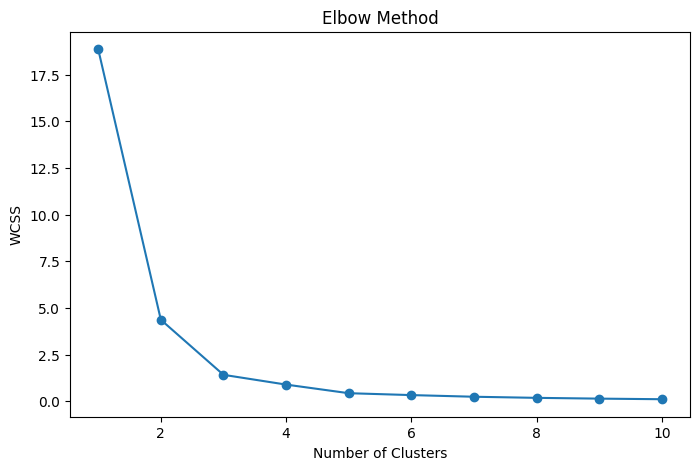

In [ ]:
# Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

print(scores)

[0.7886897082690026, 0.6991382336055124, 0.6668804375313306, 0.672655895879345, 0.6392281013118795, 0.6341980941751026, 0.5783756499354649, 0.5734146785126495, 0.56596121864808]


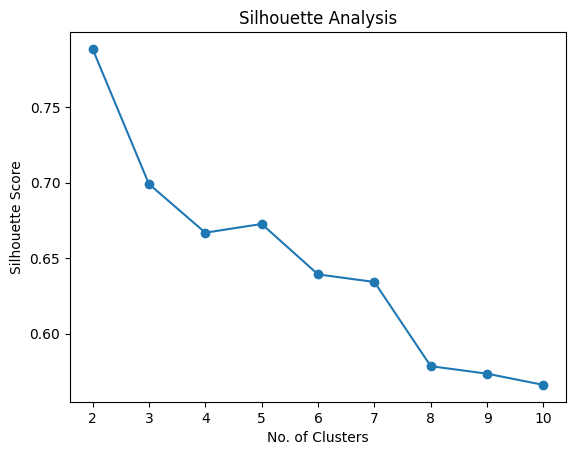

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(2,11), scores, marker='o')

plt.xlabel("No. of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

crop_ml["Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_profile = crop_ml.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile)

         Area-2020-21  Area-2021-22  Area-2022-23  Area-2023-24  Area-2024-25  \
Cluster                                                                         
0           24.722647     19.491176      9.639412      9.600882     10.906765   
1          127.203500    138.704500    149.899500    146.504000    140.560000   
2           55.820000     55.054000     54.731000     53.539000     54.869000   

         Production-2020-21  Production-2021-22  Production-2022-23  \
Cluster                                                               
0                 39.056176           19.513235            9.873824   
1                284.718000          300.095250          332.368250   
2                110.466500          110.360000          114.121000   

         Production-2023-24  Production-2024-25  Yield-2020-21  Yield-2021-22  \
Cluster                                                                         
0                  9.972941           12.930735       1.137265       1.12307

| Cluster       | Production Pattern                                                                 | Interpretation             |
| ------------- | ---------------------------------------------------------------------------------- | -------------------------- |
| **Cluster 0** | Production decreased from 39 to around 10 and showed a slight recovery in 2024–25. | Low production cluster.    |
| **Cluster 1** | Production remained consistently high (285–335) over all five years.               | High production cluster.   |
| **Cluster 2** | Production remained stable around 110–117 over all five years.                     | Medium production cluster. |


In [ ]:
crop_ml.groupby("Cluster")["Crop"].value_counts()

Cluster  Crop              
0        Jowar                 3
         Moong                 3
         Urad                  3
         Sesamum               3
         Sunflower             3
         Groundnut             2
         Other Pulses          2
         Barley                1
         Maize                 1
         Tur                   1
         Small Millets         1
         Ragi                  1
         Bajra                 1
         Linseed               1
         Nigerseed             1
         Castorseed            1
         Lentil                1
         Safflower             1
         Mesta                 1
         Tobacco               1
         Sannhemp              1
         Guarseed              1
1        Wheat                 1
         Cotton                1
         Rice                  1
         Maize                 1
         Sugarcane             1
2        Rice                  2
         Gram                  1
         Soybea

In [ ]:
crop_ml.groupby("Cluster")["Season"].value_counts()

Cluster  Season
0        Kharif    15
         Rabi      11
         Summer     8
1        Kharif     4
         Rabi       1
2        Kharif     5
         Rabi       4
         Summer     1
Name: count, dtype: int64

In [ ]:
summary = crop_ml.groupby("Cluster").agg({
    "Crop":"count",
    "Production-2020-21":"mean",
    "Production-2021-22":"mean",
    "Production-2022-23":"mean",
    "Production-2023-24":"mean",
    "Production-2024-25":"mean"
})

print(summary)

         Crop  Production-2020-21  Production-2021-22  Production-2022-23  \
Cluster                                                                     
0          34           39.056176           19.513235            9.873824   
1           5          284.718000          300.095250          332.368250   
2          10          110.466500          110.360000          114.121000   

         Production-2023-24  Production-2024-25  
Cluster                                          
0                  9.972941           12.930735  
1                319.335250          334.708750  
2                111.221000          117.355000  


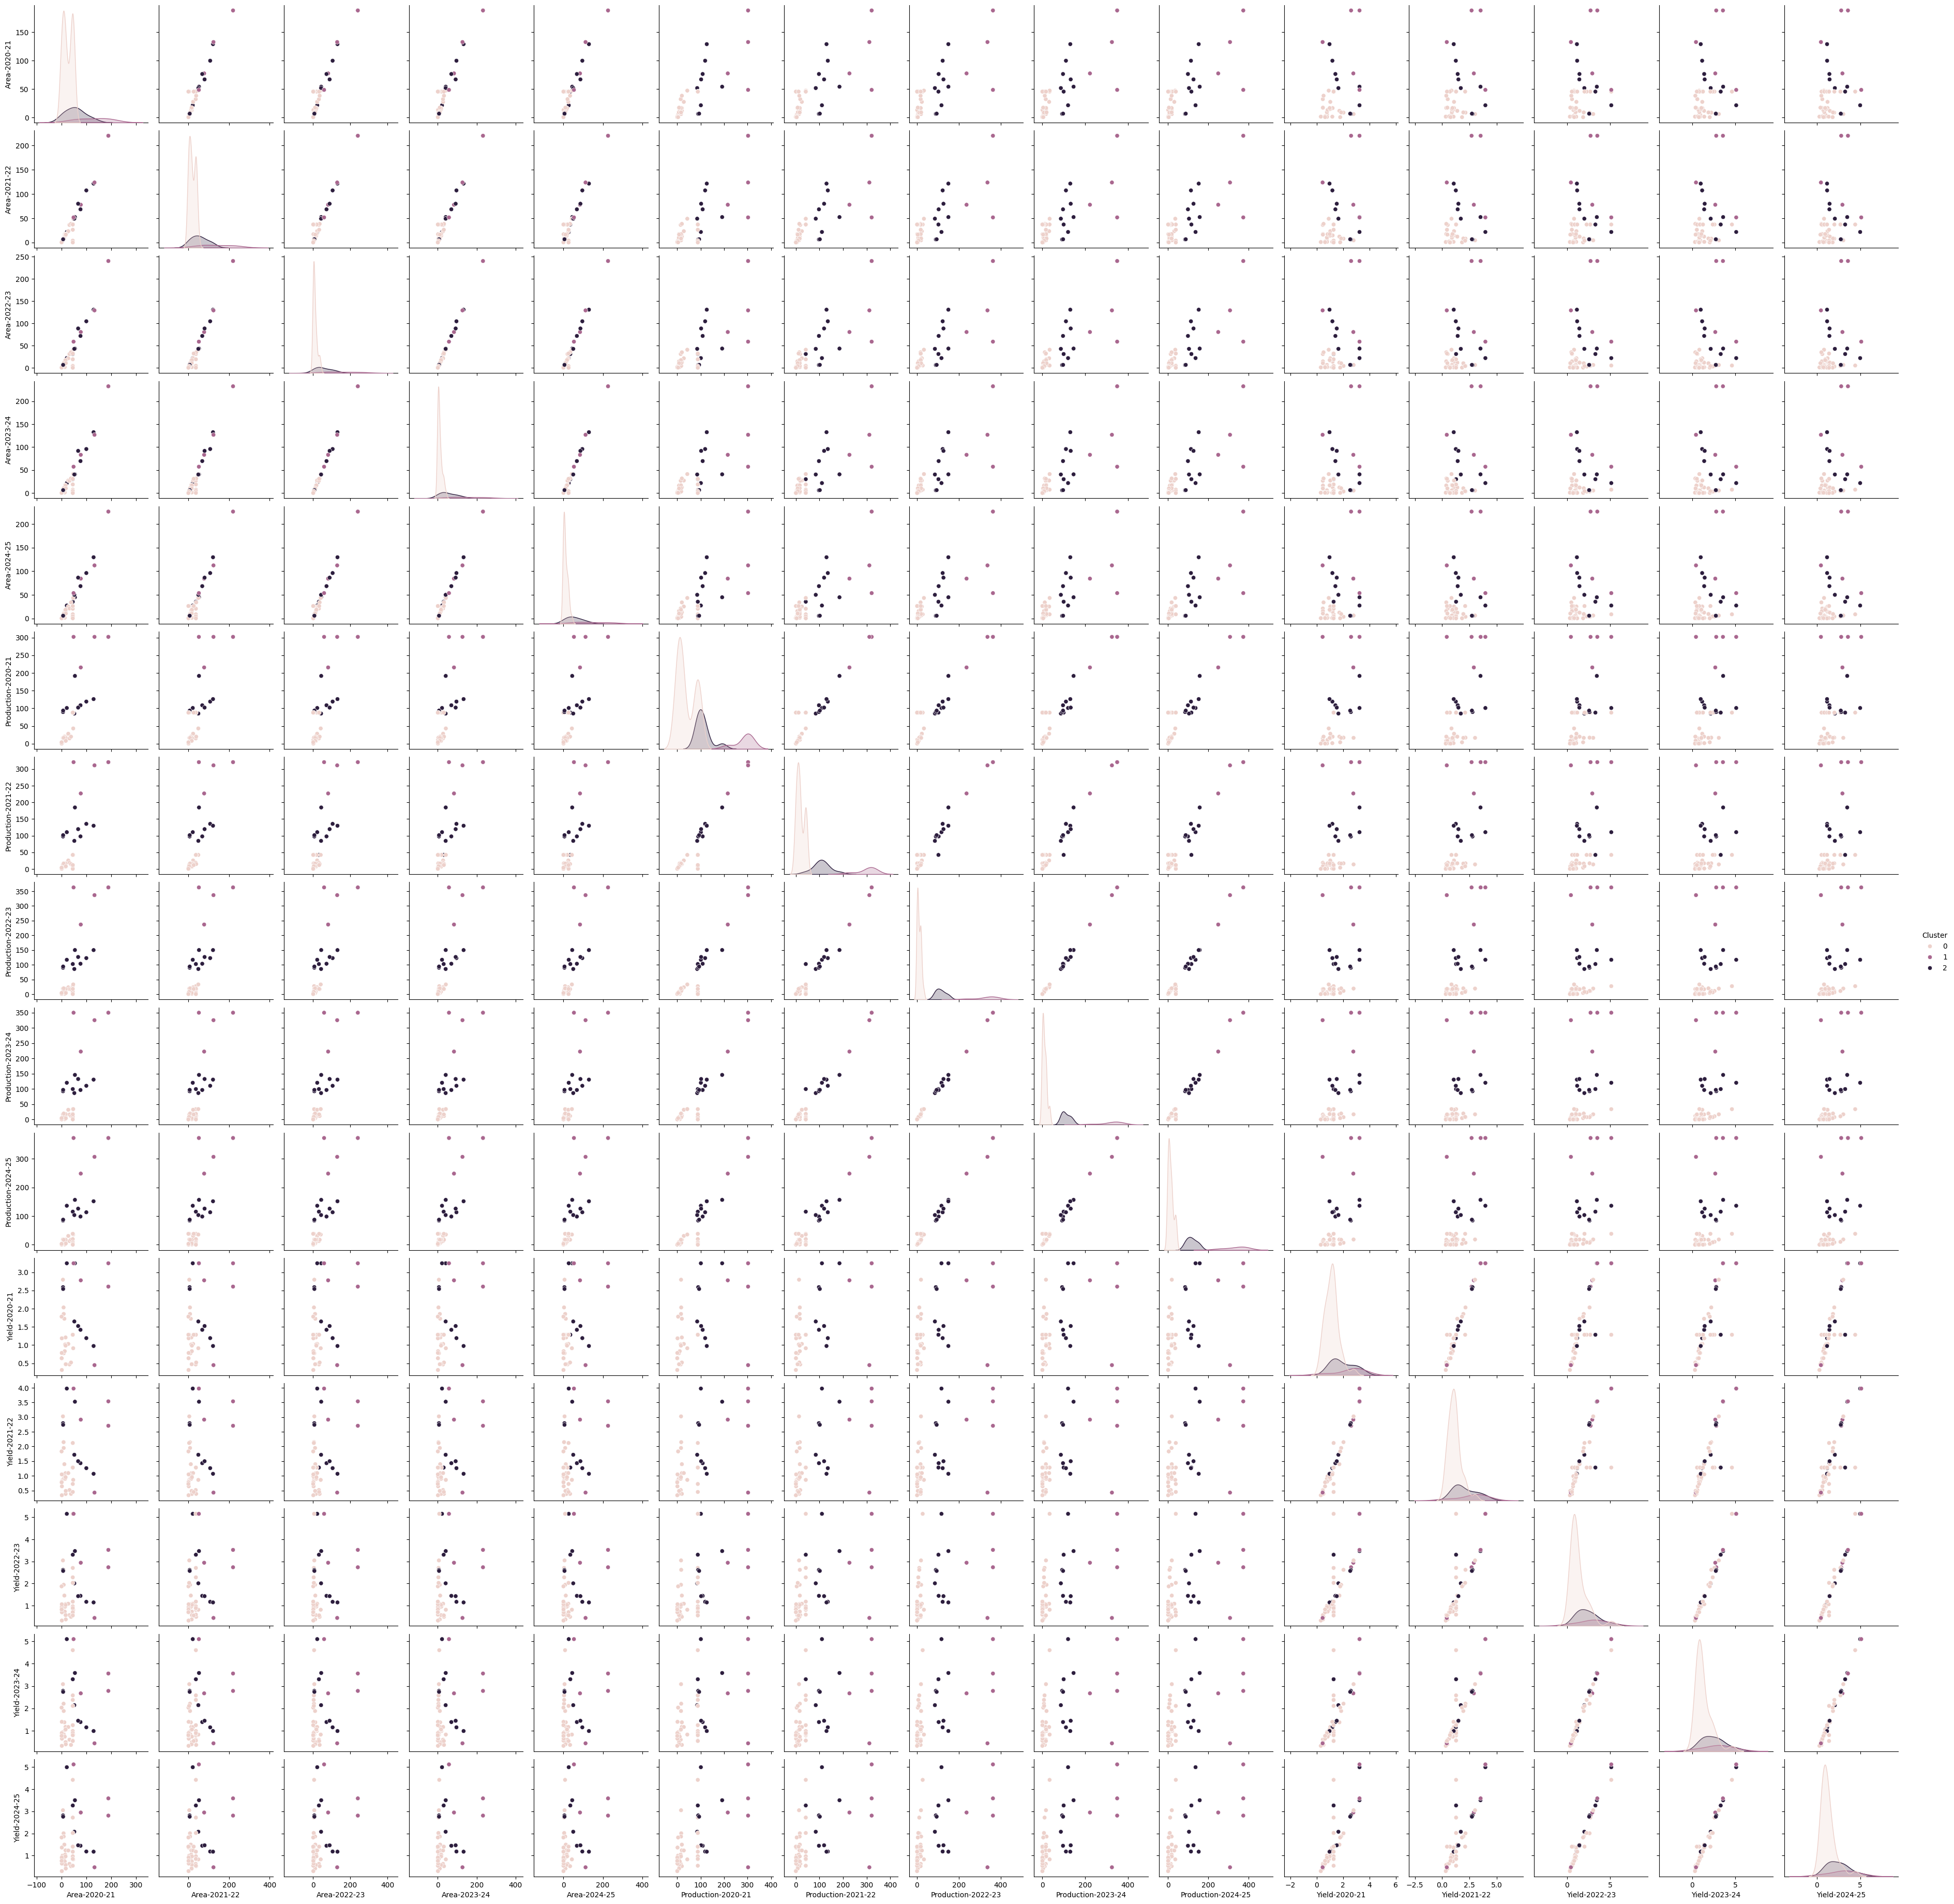

In [ ]:
sns.pairplot(data = crop_ml, hue = 'Cluster')
plt.show()

In [ ]:
for i in sorted(crop_ml["Cluster"].unique()):
    print(f"\nCluster {i}")
    print(crop_ml[crop_ml["Cluster"] == i]["Crop"].value_counts())


Cluster 0
Crop
Jowar            3
Urad             3
Moong            3
Sesamum          3
Sunflower        3
Other Pulses     2
Groundnut        2
Maize            1
Barley           1
Bajra            1
Ragi             1
Small Millets    1
Tur              1
Lentil           1
Castorseed       1
Nigerseed        1
Linseed          1
Safflower        1
Mesta            1
Tobacco          1
Sannhemp         1
Guarseed         1
Name: count, dtype: int64

Cluster 1
Crop
Rice         1
Wheat        1
Maize        1
Sugarcane    1
Cotton       1
Name: count, dtype: int64

Cluster 2
Crop
Rice                  2
Maize                 1
Bajra                 1
Gram                  1
Groundnut             1
Soybean               1
Rapeseed & Mustard    1
Jute                  1
Jute & Mesta          1
Name: count, dtype: int64


In [ ]:
for i in sorted(crop_ml["Cluster"].unique()):
    print(f"\nCluster {i}")
    print(crop_ml[crop_ml["Cluster"] == i]["Season"].value_counts())


Cluster 0
Season
Kharif    15
Rabi      11
Summer     8
Name: count, dtype: int64

Cluster 1
Season
Kharif    4
Rabi      1
Name: count, dtype: int64

Cluster 2
Season
Kharif    5
Rabi      4
Summer    1
Name: count, dtype: int64


In [ ]:
for cluster in sorted(crop_ml["Cluster"].unique()):

    print("="*70)
    print(f"Cluster {cluster}")
    print("="*70)

    print(f"\nNumber of Records : {len(crop_ml[crop_ml['Cluster']==cluster])}")

    print("\nCrops:")
    print(crop_ml[crop_ml["Cluster"]==cluster]["Crop"].value_counts())

    print("\nSeason Distribution:")
    print(crop_ml[crop_ml["Cluster"]==cluster]["Season"].value_counts())

    print("\nAverage Production")

    print(
        crop_ml[crop_ml["Cluster"]==cluster][[
            "Production-2020-21",
            "Production-2021-22",
            "Production-2022-23",
            "Production-2023-24",
            "Production-2024-25"
        ]].mean()
    )

    print("\n")

Cluster 0

Number of Records : 34

Crops:
Crop
Jowar            3
Urad             3
Moong            3
Sesamum          3
Sunflower        3
Other Pulses     2
Groundnut        2
Maize            1
Barley           1
Bajra            1
Ragi             1
Small Millets    1
Tur              1
Lentil           1
Castorseed       1
Nigerseed        1
Linseed          1
Safflower        1
Mesta            1
Tobacco          1
Sannhemp         1
Guarseed         1
Name: count, dtype: int64

Season Distribution:
Season
Kharif    15
Rabi      11
Summer     8
Name: count, dtype: int64

Average Production
Production-2020-21    39.056176
Production-2021-22    19.513235
Production-2022-23     9.873824
Production-2023-24     9.972941
Production-2024-25    12.930735
dtype: float64


Cluster 1

Number of Records : 5

Crops:
Crop
Rice         1
Wheat        1
Maize        1
Sugarcane    1
Cotton       1
Name: count, dtype: int64

Season Distribution:
Season
Kharif    4
Rabi      1
Name: count, dtype

In [ ]:
for cluster in sorted(crop_ml["Cluster"].unique()):

    print("="*60)
    print(f"Cluster {cluster}")
    print("="*60)

    print(
        crop_ml[crop_ml["Cluster"] == cluster]
        .sort_values(["Crop", "Season"])
        [["Crop", "Season"]]
    )

    print("\n")

Cluster 0
              Crop  Season
17           Bajra  Summer
10          Barley    Rabi
64      Castorseed  Kharif
61       Groundnut    Rabi
62       Groundnut  Summer
102       Guarseed  Kharif
12           Jowar  Kharif
13           Jowar    Rabi
14           Jowar  Summer
47          Lentil    Rabi
80         Linseed    Rabi
8            Maize  Summer
94           Mesta  Kharif
43           Moong  Kharif
44           Moong    Rabi
45           Moong  Summer
70       Nigerseed  Kharif
49    Other Pulses  Kharif
50    Other Pulses    Rabi
19            Ragi  Kharif
82       Safflower    Rabi
100       Sannhemp  Kharif
66         Sesamum  Kharif
67         Sesamum    Rabi
68         Sesamum  Summer
21   Small Millets  Kharif
74       Sunflower  Kharif
75       Sunflower    Rabi
76       Sunflower  Summer
98         Tobacco  Kharif
35             Tur  Kharif
39            Urad  Kharif
40            Urad    Rabi
41            Urad  Summer


Cluster 1
         Crop  Season
90     Cott

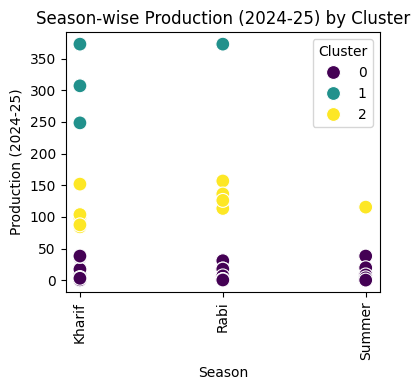

In [ ]:
plt.figure(figsize=(4,4))

sns.scatterplot(
    data=crop_ml,
    x="Season",
    y="Production-2024-25",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.xticks(rotation=90)
plt.title("Season-wise Production (2024-25) by Cluster")
plt.xlabel("Season")
plt.ylabel("Production (2024-25)")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

In [ ]:
cluster_labels = {
    0: "Low Production",
    1: "High Production",
    2: "Medium Production"
}

crop_ml["Cluster_Label"] = crop_ml["Cluster"].map(cluster_labels)

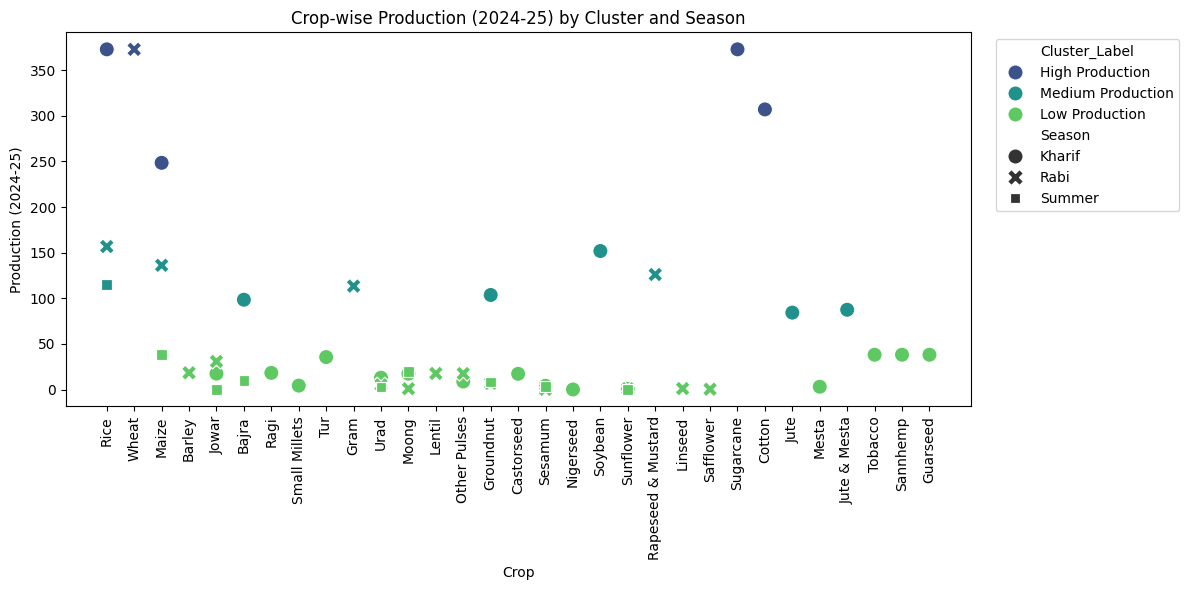

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=crop_ml,
    x="Crop",
    y="Production-2024-25",
    hue="Cluster_Label",
    style="Season",
    palette="viridis",
    s=120
)
plt.xticks(rotation=90)
plt.title("Crop-wise Production (2024-25) by Cluster and Season")
plt.xlabel("Crop")
plt.ylabel("Production (2024-25)")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

Clusters crop-season combinations based on five years of production data, enabling better crop planning, resource allocation, and productivity analysis.


| Cluster | Cluster Label                 | Crop–Season Combinations                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | Average Production (2020–21 to 2024–25)        |
| ------- | ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| **0**   | **Low Production Cluster**    | Bajra (Summer), Barley (Rabi), Castorseed (Kharif), Groundnut (Rabi & Summer), Guarseed (Kharif), Jowar (Kharif, Rabi & Summer), Lentil (Rabi), Linseed (Rabi), Maize (Summer), Mesta (Kharif), Moong (Kharif, Rabi & Summer), Nigerseed (Kharif), Other Pulses (Kharif & Rabi), Ragi (Kharif), Safflower (Rabi), Sannhemp (Kharif), Sesamum (Kharif, Rabi & Summer), Small Millets (Kharif), Sunflower (Kharif, Rabi & Summer), Tobacco (Kharif), Tur (Kharif), Urad (Kharif, Rabi & Summer) | **39.06 → 19.51 → 9.87 → 9.97 → 12.93**        |
| **1**   | **High Production Cluster**   | Rice (Kharif), Maize (Kharif), Wheat (Rabi), Sugarcane (Kharif), Cotton (Kharif)                                                                                                                                                                                                                                                                                                                                                                                                              | **284.72 → 300.10 → 332.37 → 319.34 → 334.71** |
| **2**   | **Medium Production Cluster** | Bajra (Kharif), Gram (Rabi), Groundnut (Kharif), Jute (Kharif), Jute & Mesta (Kharif), Maize (Rabi), Rapeseed & Mustard (Rabi), Rice (Rabi & Summer), Soybean (Kharif)                                                                                                                                                                                                                                                                                                                        | **110.47 → 110.36 → 114.12 → 111.22 → 117.36** |


Key Insights
Cluster 0 (Low Production): Contains mostly pulses, oilseeds, and coarse cereals. These crop–season combinations consistently recorded the lowest production over the five-year period.
Cluster 1 (High Production): Contains major staple and commercial crops, primarily grown in the Kharif season. This cluster maintained the highest production across all five years.
Cluster 2 (Medium Production): Represents crop–season combinations with moderate and stable production, mainly from Kharif and Rabi seasons.
Interesting Observation

Some crops appear in more than one cluster because season affects their production pattern. For example:

Crop	Cluster Assignment
Rice	Kharif → High, Rabi & Summer → Medium
Maize	Kharif → High, Rabi → Medium, Summer → Low
Groundnut	Kharif → Medium, Rabi & Summer → Low
Bajra	Kharif → Medium, Summer → Low

This demonstrates that the clustering is identifying crop–season production patterns, not just crop types, which is an important insight from your analysis.

Benefits specific to this analysis

the model revealed that:

Cluster 1 contains high-production crop-season combinations, such as Rice (Kharif), Maize (Kharif), Wheat (Rabi), Sugarcane (Kharif), and Cotton (Kharif).
Cluster 0 contains low-production crop-season combinations, mainly pulses, oilseeds, and coarse cereals.
Cluster 2 contains medium-production crop-season combinations with stable production.

An important insight is that the same crop can belong to different clusters depending on the season. This indicates that season has a significant influence on production performance, and agricultural planning should consider both the crop and the season, rather than treating each crop as having a single production profile.

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# X_scaled is the data used to train KMeans
# kmeans is your fitted KMeans model

sil_score = silhouette_score(X_scaled, kmeans.labels_)
ch_score = calinski_harabasz_score(X_scaled, kmeans.labels_)
db_score = davies_bouldin_score(X_scaled, kmeans.labels_)

print(f"Silhouette Score        : {sil_score:.4f}")
print(f"Calinski-Harabasz Score : {ch_score:.4f}")
print(f"Davies-Bouldin Index    : {db_score:.4f}")

Silhouette Score        : 0.6991
Calinski-Harabasz Score : 282.4097
Davies-Bouldin Index    : 0.4115


Silhouette Score (0.6991): Indicates good separation between the three clusters.
Calinski-Harabasz Score (282.41): Confirms that the clusters are compact and well separated.
Davies-Bouldin Index (0.4115): A low value indicating that the clusters have minimal overlap and good clustering quality.